# 2026-05-26 Te Metallicity Map Check

This notebook inspects the new `SFR+Z.py` PyNeb products written to `v3tk_v7.6.8/<galaxy>/*_gas_BIN_maps_further.fits` or `*_gas_bin_maps_further.fits`.

The main loop makes one 2x2 figure per available galaxy for `NE_SII`, `O_H_O3N2_M13_HII`, `O_H_NII_OII7325_HII`, and `O_H_NII_K25_HII`. All O/H maps are HII-gated.

In [1]:

from __future__ import annotations

import math
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.io import fits
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
RUN_LABEL = "v3tk_v7.6.8"
RUN_DIR = PROJECT_ROOT / RUN_LABEL
OUTDIR = PROJECT_ROOT / "quicklook_figures"

TARGET_MAP_SPECS = [
    {
        "hdu": "NE_SII",
        "label": "log10 ne[SII] / cm^-3",
        "table_label": "ne[SII] cm^-3",
        "cmap": "viridis",
        "transform": "log10_positive",
    },
    {
        "hdu": "O_H_O3N2_M13_HII",
        "label": "12+log(O/H) O3N2-M13 HII",
        "table_label": "O/H O3N2-M13 HII",
        "cmap": "plasma",
        "transform": "identity",
    },
    {
        "hdu": "O_H_NII_OII7325_HII",
        "label": "12+log(O/H) NII+OII7325 HII",
        "table_label": "O/H NII+OII7325 HII",
        "cmap": "magma",
        "transform": "identity",
    },
    {
        "hdu": "O_H_NII_K25_HII",
        "label": "12+log(O/H) NII-K25 HII",
        "table_label": "O/H NII-K25 HII",
        "cmap": "cividis",
        "transform": "identity",
    },
]

TARGET_HDUS = [spec["hdu"] for spec in TARGET_MAP_SPECS]
VALID_MASK_HDUS = ["NII_OII7325_VALID_HII", "NII_K25_VALID_HII"]
QC_HDUS = ["NE_SII", "NE_SII_FIXED20", "TE_NII_HII", *VALID_MASK_HDUS]
MAX_SCATTER_POINTS_PER_GALAXY = 5000
RNG = np.random.default_rng(20260526)

plt.style.use("default")
mpl.rcParams.update({
    "figure.dpi": 120,
    "font.size": 10,
    "axes.grid": False,
})

print(f"Project root: {PROJECT_ROOT}")
print(f"Run directory: {RUN_DIR}")
print("Figure save paths are intentionally present but commented out.")


Project root: /Users/Igniz/Desktop/ICRAR/further
Run directory: /Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8
Figure save paths are intentionally present but commented out.


In [2]:

def first_existing(*paths: Path | None) -> Path | None:
    for path in paths:
        if path is not None and path.exists():
            return path
    return None


def hdu_name_map(path: Path) -> dict[str, str]:
    """Return uppercase HDU name -> exact HDU name for case-insensitive lookup."""
    with fits.open(path, memmap=True) as hdul:
        return {hdu.name.upper(): hdu.name for hdu in hdul}


def fits_has_hdus(path: Path | None, names: list[str]) -> bool:
    if path is None or not path.exists():
        return False
    try:
        names_upper = set(hdu_name_map(path))
    except Exception:
        return False
    return all(name.upper() in names_upper for name in names)


def read_hdu(path: Path | None, name: str, *, dtype=float, required: bool = False) -> np.ndarray | None:
    if path is None or not path.exists():
        if required:
            raise FileNotFoundError(f"Missing FITS path for {name}: {path}")
        return None
    try:
        with fits.open(path, memmap=True) as hdul:
            exact_name = {hdu.name.upper(): hdu.name for hdu in hdul}.get(name.upper())
            if exact_name is None:
                if required:
                    raise KeyError(f"Missing HDU {name} in {path}")
                return None
            data = hdul[exact_name].data
            if data is None:
                if required:
                    raise ValueError(f"HDU {name} has no data in {path}")
                return None
            return np.asarray(data, dtype=dtype)
    except Exception as exc:
        if required:
            raise
        print(f"Could not read {name} from {path}: {exc}")
        return None


def align_map_to_shape(map_data, target_shape, *, label="map", fill_value=np.nan, max_delta=2):
    """Align a nearly matching 2D map to target_shape by copying the overlap."""
    target_shape = tuple(target_shape)
    arr = np.asarray(map_data, dtype=float)
    if arr.shape == target_shape:
        return arr
    if arr.ndim != len(target_shape):
        raise ValueError(f"{label}: cannot align ndim {arr.ndim} to target shape {target_shape}")

    deltas = tuple(abs(src - dst) for src, dst in zip(arr.shape, target_shape))
    if any(delta > max_delta for delta in deltas):
        raise ValueError(f"{label}: shape {arr.shape} differs too much from target {target_shape}")

    aligned = np.full(target_shape, fill_value, dtype=float)
    overlap = tuple(min(src, dst) for src, dst in zip(arr.shape, target_shape))
    slices = tuple(slice(0, n) for n in overlap)
    aligned[slices] = arr[slices]
    print(f"  {label}: aligned shape {arr.shape} -> {target_shape}; overlap={overlap}")
    return aligned


def display_transform(data: np.ndarray | None, transform: str) -> np.ndarray | None:
    if data is None:
        return None
    arr = np.asarray(data, dtype=float)
    if transform == "log10_positive":
        out = np.full(arr.shape, np.nan, dtype=float)
        ok = np.isfinite(arr) & (arr > 0)
        out[ok] = np.log10(arr[ok])
        return out
    if transform == "identity":
        return arr
    raise ValueError(f"Unknown transform: {transform}")


def finite_values(data: np.ndarray | None) -> np.ndarray:
    if data is None:
        return np.array([], dtype=float)
    arr = np.asarray(data, dtype=float)
    return arr[np.isfinite(arr)]


def robust_limits_from_values(values: np.ndarray, qlo: float = 2, qhi: float = 98) -> tuple[float | None, float | None]:
    values = values[np.isfinite(values)]
    if values.size == 0:
        return None, None
    if values.size < 3:
        vmin, vmax = float(np.nanmin(values)), float(np.nanmax(values))
    else:
        vmin, vmax = np.nanpercentile(values, [qlo, qhi])
        vmin, vmax = float(vmin), float(vmax)
    if not np.isfinite(vmin) or not np.isfinite(vmax):
        return None, None
    if vmin == vmax:
        pad = 0.05 * abs(vmin) if vmin != 0 else 0.05
        vmin -= pad
        vmax += pad
    return vmin, vmax


def finite_stats(data: np.ndarray | None) -> dict[str, float | int]:
    vals = finite_values(data)
    if vals.size == 0:
        return {
            "finite_count": 0,
            "nonzero_count": 0,
            "median": np.nan,
            "min": np.nan,
            "max": np.nan,
        }
    return {
        "finite_count": int(vals.size),
        "nonzero_count": int(np.count_nonzero(vals)),
        "median": float(np.nanmedian(vals)),
        "min": float(np.nanmin(vals)),
        "max": float(np.nanmax(vals)),
    }


def iter_gas_product_paths(run_dir: Path) -> list[Path]:
    patterns = (
        "*/*_gas_BIN_maps_further.fits",
        "*/*_gas_bin_maps_further.fits",
        "*/*_gas_BIN_maps_further.fits.gz",
        "*/*_gas_bin_maps_further.fits.gz",
    )
    paths: list[Path] = []
    seen: set[Path] = set()
    for pattern in patterns:
        for path in sorted(run_dir.glob(pattern)):
            key = path.resolve()
            if key in seen:
                continue
            seen.add(key)
            paths.append(path)
    return sorted(paths, key=lambda path: path.parent.name)


def discover_te_products(run_dir: Path = RUN_DIR) -> pd.DataFrame:
    if not run_dir.exists():
        raise FileNotFoundError(f"Missing run directory: {run_dir}")

    rows = []
    for gas_path in iter_gas_product_paths(run_dir):
        gal = gas_path.parent.name
        folder = gas_path.parent
        spatial_path = first_existing(
            folder / f"{gal}_spatial_binning_maps_further.fits",
            folder / f"{gal}_spatial_binning_maps_extended.fits",
            folder / f"{gal}_spatial_binning_maps.fits",
        )
        try:
            hdu_names = set(hdu_name_map(gas_path))
            readable = True
        except Exception as exc:
            print(f"Could not inspect {gas_path}: {exc}")
            hdu_names = set()
            readable = False

        row = {
            "galaxy": gal,
            "folder": folder,
            "gas_path": gas_path,
            "spatial_path": spatial_path,
            "readable": readable,
            "has_spatial_mass": fits_has_hdus(spatial_path, ["LOGMASS_SURFACE_DENSITY"]),
            "has_logsfr_hii": "LOGSFR_SURFACE_DENSITY_HII" in hdu_names,
        }
        for name in TARGET_HDUS + VALID_MASK_HDUS + ["TE_NII_HII", "NE_SII_FIXED20"]:
            row[f"has_{name}"] = name.upper() in hdu_names
        row["has_all_target_hdus"] = all(row[f"has_{name}"] for name in TARGET_HDUS)
        rows.append(row)

    table = pd.DataFrame(rows)
    if table.empty:
        raise RuntimeError(f"No gas map products found below {run_dir}")
    table = table.sort_values("galaxy").set_index("galaxy", drop=False)
    return table


PRODUCTS = discover_te_products()
AVAILABLE_GALAXIES = PRODUCTS.index[PRODUCTS["has_all_target_hdus"]].tolist()
EXCLUDED_GALAXIES = PRODUCTS.index[~PRODUCTS["has_all_target_hdus"]].tolist()

print(f"Discovered {len(PRODUCTS)} gas map products.")
print(f"Available target-HDU galaxies: {len(AVAILABLE_GALAXIES)}")
if AVAILABLE_GALAXIES:
    print(", ".join(AVAILABLE_GALAXIES))
if EXCLUDED_GALAXIES:
    print("Excluded because target HDUs are missing:", ", ".join(EXCLUDED_GALAXIES))

display_columns = [
    "readable",
    "has_all_target_hdus",
    "has_NE_SII",
    "has_O_H_O3N2_M13_HII",
    "has_O_H_NII_OII7325_HII",
    "has_O_H_NII_K25_HII",
    "has_NII_OII7325_VALID_HII",
    "has_NII_K25_VALID_HII",
    "has_TE_NII_HII",
    "has_NE_SII_FIXED20",
    "has_logsfr_hii",
    "has_spatial_mass",
]
display(PRODUCTS[display_columns])


Discovered 18 gas map products.
Available target-HDU galaxies: 18
IC3392, NGC4064, NGC4189, NGC4192, NGC4293, NGC4294, NGC4351, NGC4394, NGC4402, NGC4405, NGC4501, NGC4522, NGC4567_8, NGC4580, NGC4606, NGC4607, NGC4694, NGC4698


,readable,has_all_target_hdus,has_NE_SII,has_O_H_O3N2_M13_HII,has_O_H_NII_OII7325_HII,has_O_H_NII_K25_HII,has_NII_OII7325_VALID_HII,has_NII_K25_VALID_HII,has_TE_NII_HII,has_NE_SII_FIXED20,has_logsfr_hii,has_spatial_mass
galaxy,,,,,,,,,,,,
IC3392,True,True,True,True,True,True,True,True,True,True,True,True
NGC4064,True,True,True,True,True,True,True,True,True,True,True,True
NGC4189,True,True,True,True,True,True,True,True,True,True,True,True
NGC4192,True,True,True,True,True,True,True,True,True,True,True,True
NGC4293,True,True,True,True,True,True,True,True,True,True,True,True
NGC4294,True,True,True,True,True,True,True,True,True,True,True,True
NGC4351,True,True,True,True,True,True,True,True,True,True,True,True
NGC4394,True,True,True,True,True,True,True,True,True,True,True,True
NGC4402,True,True,True,True,True,True,True,True,True,True,True,True


In [3]:

def build_availability_table(galaxies: list[str] = AVAILABLE_GALAXIES) -> pd.DataFrame:
    rows = []
    hdu_labels = {spec["hdu"]: spec["table_label"] for spec in TARGET_MAP_SPECS}
    hdu_labels.update({
        "NII_OII7325_VALID_HII": "valid mask NII+OII7325 HII",
        "NII_K25_VALID_HII": "valid mask NII-K25 HII",
    })
    for gal in galaxies:
        path = PRODUCTS.loc[gal, "gas_path"]
        for hdu_name in TARGET_HDUS + VALID_MASK_HDUS:
            data = read_hdu(path, hdu_name, dtype=float, required=False)
            stats = finite_stats(data)
            rows.append({
                "galaxy": gal,
                "hdu": hdu_name,
                "label": hdu_labels[hdu_name],
                **stats,
            })
    return pd.DataFrame(rows)


AVAILABILITY = build_availability_table()
print(f"Availability rows: {len(AVAILABILITY)}")

finite_count_grid = AVAILABILITY.pivot(index="galaxy", columns="hdu", values="finite_count")
nonzero_count_grid = AVAILABILITY.pivot(index="galaxy", columns="hdu", values="nonzero_count")
median_grid = AVAILABILITY.pivot(index="galaxy", columns="hdu", values="median")

print("Finite-pixel counts:")
display(finite_count_grid[TARGET_HDUS + VALID_MASK_HDUS].astype("Int64"))
print("Nonzero-pixel counts (useful for integer valid masks):")
display(nonzero_count_grid[TARGET_HDUS + VALID_MASK_HDUS].astype("Int64"))
print("Medians:")
display(median_grid[TARGET_HDUS + VALID_MASK_HDUS].round(4))


Availability rows: 108
Finite-pixel counts:


hdu,NE_SII,O_H_O3N2_M13_HII,O_H_NII_OII7325_HII,O_H_NII_K25_HII,NII_OII7325_VALID_HII,NII_K25_VALID_HII
galaxy,,,,,,
IC3392,22573,14825,11,0,191406,191406
NGC4064,34546,6959,2,212,376390,376390
NGC4189,135548,99848,279,56,190762,190762
NGC4192,432021,154943,718,517,1778868,1778868
NGC4293,50685,4580,0,0,491036,491036
NGC4294,132146,68126,1669,1362,375921,375921
NGC4351,51600,30940,195,177,190893,190893
NGC4394,49814,42663,0,0,403728,403728
NGC4402,94883,52886,5,0,366336,366336


Nonzero-pixel counts (useful for integer valid masks):


hdu,NE_SII,O_H_O3N2_M13_HII,O_H_NII_OII7325_HII,O_H_NII_K25_HII,NII_OII7325_VALID_HII,NII_K25_VALID_HII
galaxy,,,,,,
IC3392,22573,14825,11,0,29,0
NGC4064,34546,6959,2,212,2,212
NGC4189,135548,99848,279,56,279,56
NGC4192,432021,154943,718,517,718,517
NGC4293,50685,4580,0,0,0,0
NGC4294,132146,68126,1669,1362,1678,1362
NGC4351,51600,30940,195,177,195,177
NGC4394,49814,42663,0,0,0,0
NGC4402,94883,52886,5,0,5,0


Medians:


hdu,NE_SII,O_H_O3N2_M13_HII,O_H_NII_OII7325_HII,O_H_NII_K25_HII,NII_OII7325_VALID_HII,NII_K25_VALID_HII
galaxy,,,,,,
IC3392,20.0000,8.5708,7.3184,NaN,0.0,0.0
NGC4064,20.0000,8.5570,7.9630,8.4230,0.0,0.0
NGC4189,20.0000,8.5465,8.7770,8.4365,0.0,0.0
NGC4192,20.0000,8.5642,8.4110,8.6177,0.0,0.0
NGC4293,23.0401,8.5127,NaN,NaN,0.0,0.0
NGC4294,20.0000,8.3631,8.2205,8.5051,0.0,0.0
NGC4351,20.0000,8.4947,7.9076,8.4984,0.0,0.0
NGC4394,20.0000,8.5879,NaN,NaN,0.0,0.0
NGC4402,20.0000,8.5712,6.9302,NaN,0.0,0.0


In [4]:

def collect_display_values(hdu_name: str, transform: str, galaxies: list[str] = AVAILABLE_GALAXIES) -> np.ndarray:
    pieces = []
    for gal in galaxies:
        path = PRODUCTS.loc[gal, "gas_path"]
        data = read_hdu(path, hdu_name, dtype=float, required=False)
        display_data = display_transform(data, transform)
        vals = finite_values(display_data)
        if vals.size:
            pieces.append(vals)
    if not pieces:
        return np.array([], dtype=float)
    return np.concatenate(pieces)


def build_display_limits() -> dict[str, tuple[float | None, float | None]]:
    limits = {}
    rows = []
    for spec in TARGET_MAP_SPECS:
        vals = collect_display_values(spec["hdu"], spec["transform"])
        vmin, vmax = robust_limits_from_values(vals)
        limits[spec["hdu"]] = (vmin, vmax)
        rows.append({
            "hdu": spec["hdu"],
            "display_label": spec["label"],
            "display_finite_values": int(vals.size),
            "display_vmin": vmin,
            "display_vmax": vmax,
        })
    display(pd.DataFrame(rows).set_index("hdu"))
    return limits


DISPLAY_LIMITS = build_display_limits()


,display_label,display_finite_values,display_vmin,display_vmax
hdu,,,,
NE_SII,log10 ne[SII] / cm^-3,2199720,1.301030,2.685690
O_H_O3N2_M13_HII,12+log(O/H) O3N2-M13 HII,1090994,8.336128,8.660166
O_H_NII_OII7325_HII,12+log(O/H) NII+OII7325 HII,3324,7.016151,9.007656
O_H_NII_K25_HII,12+log(O/H) NII-K25 HII,3502,8.150515,8.721050


Making Te-metallicity 2x2 figures for 18 galaxies.


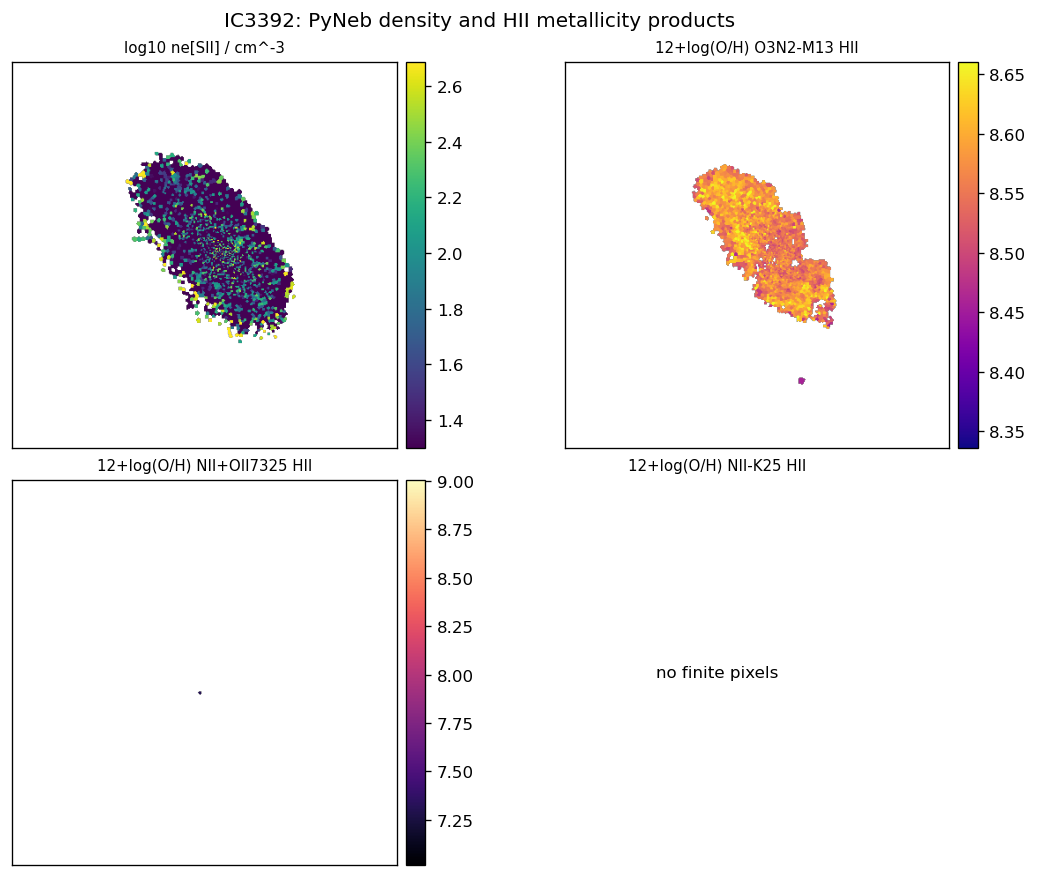

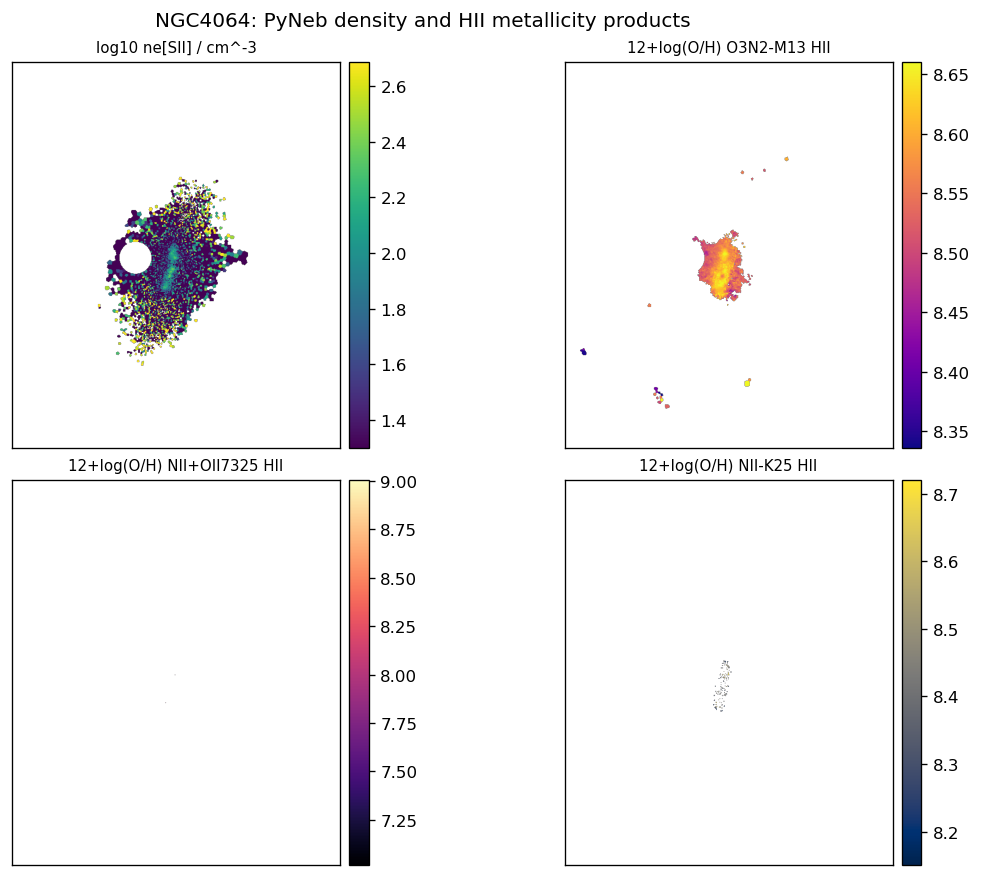

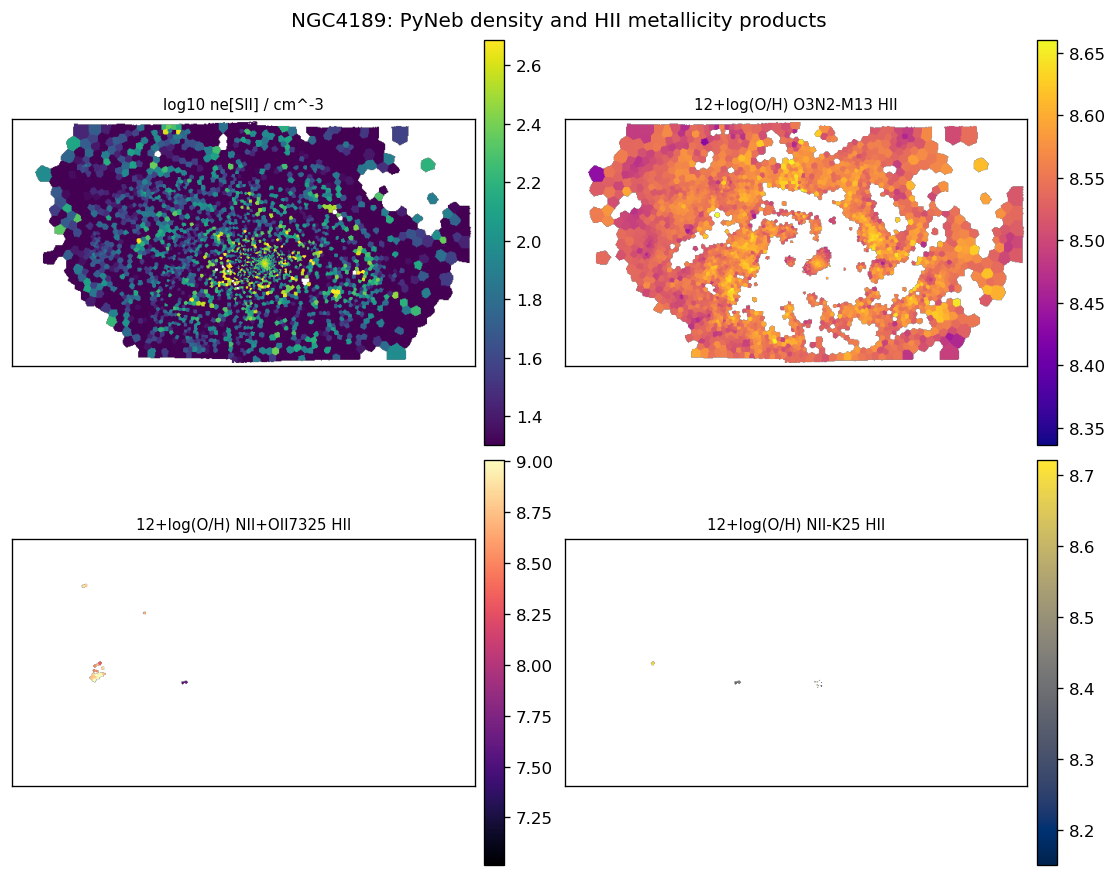

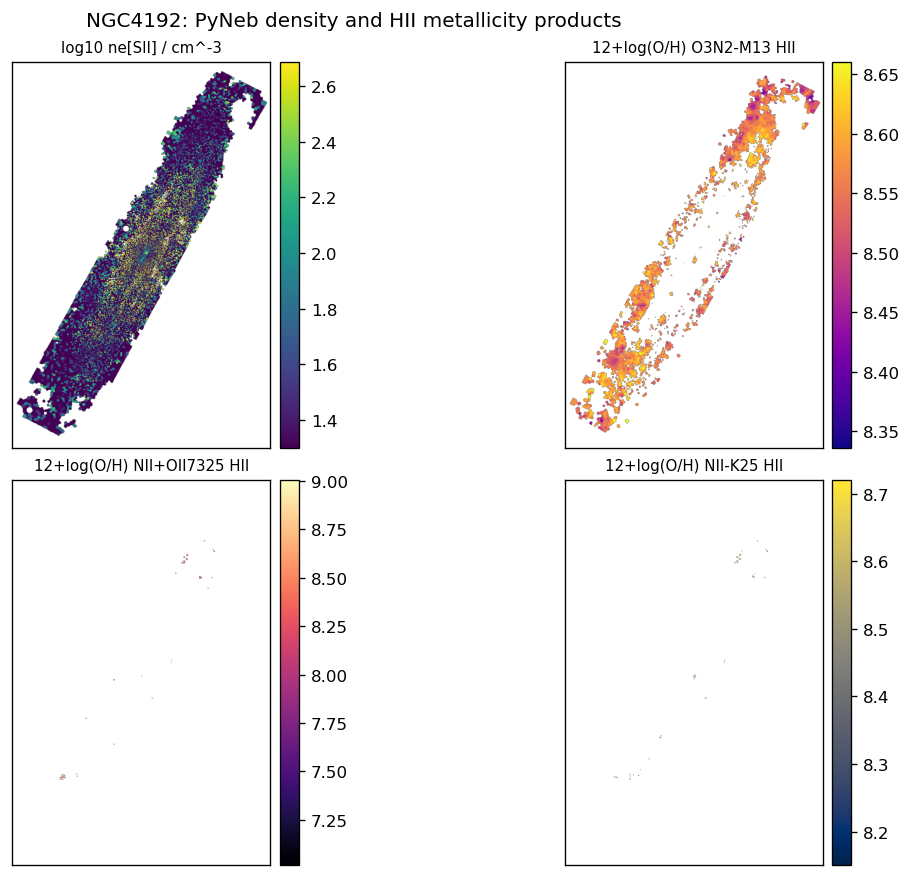

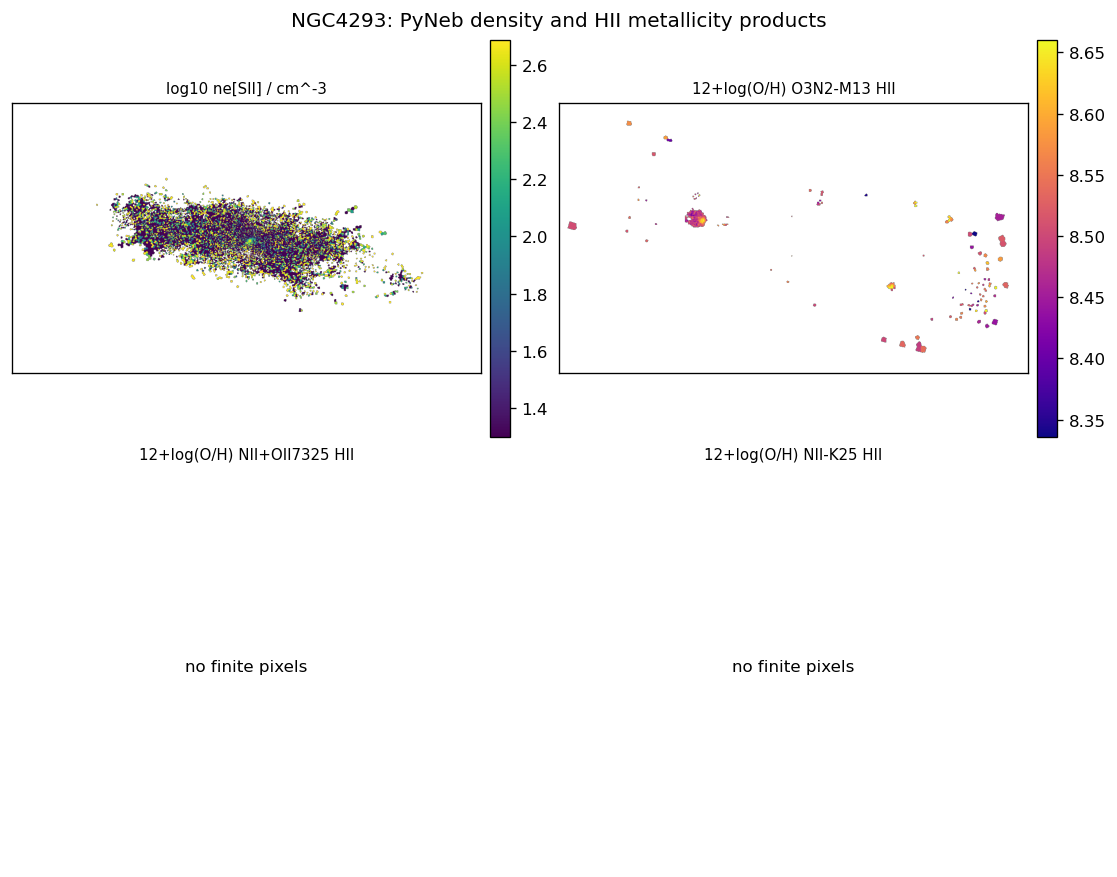

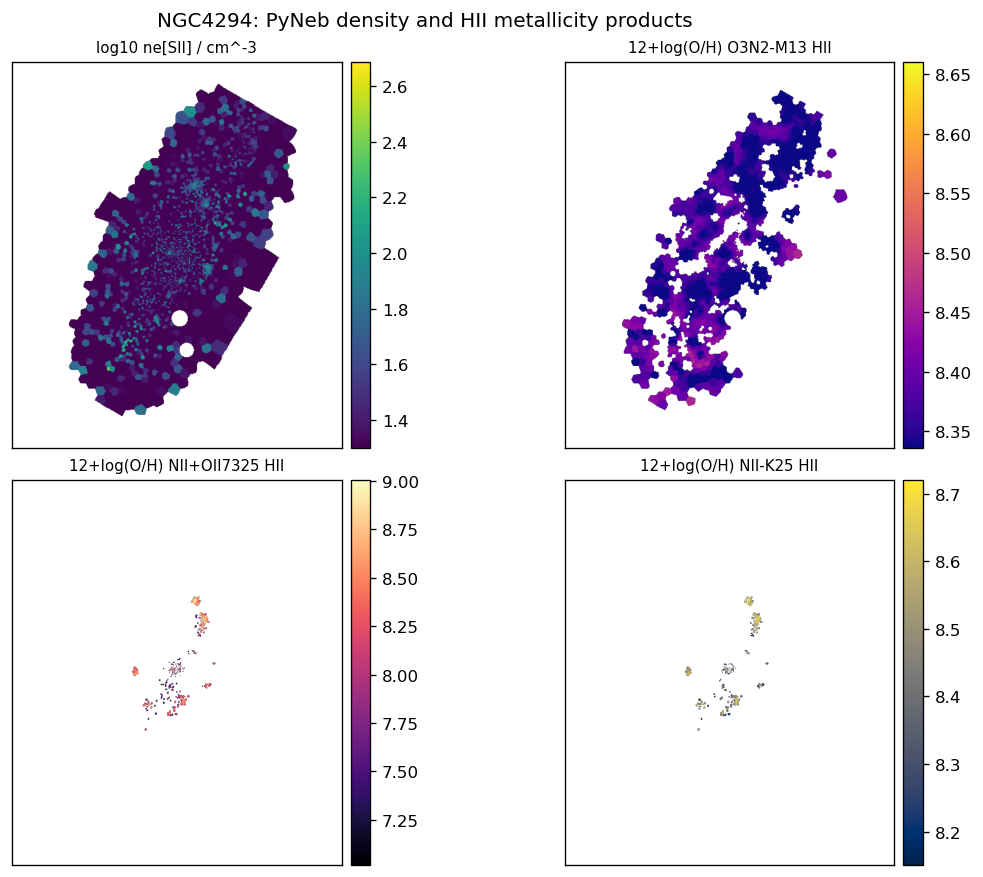

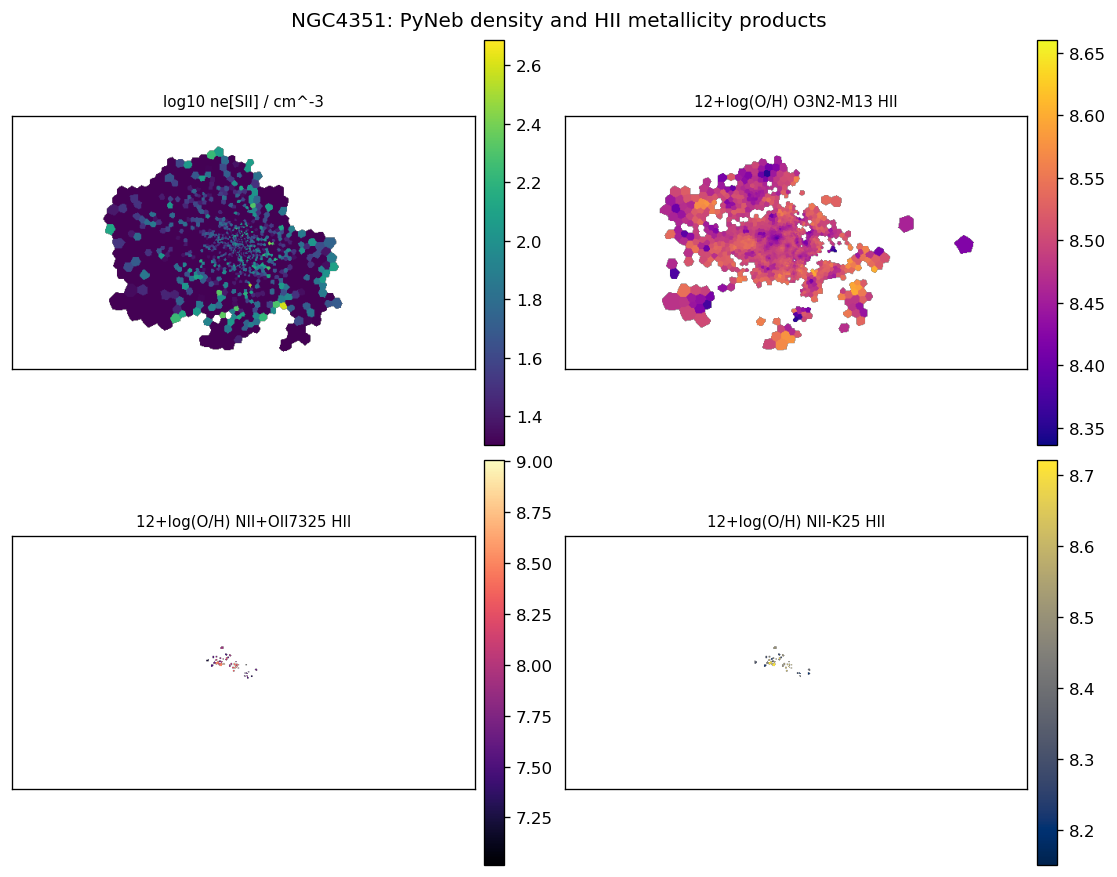

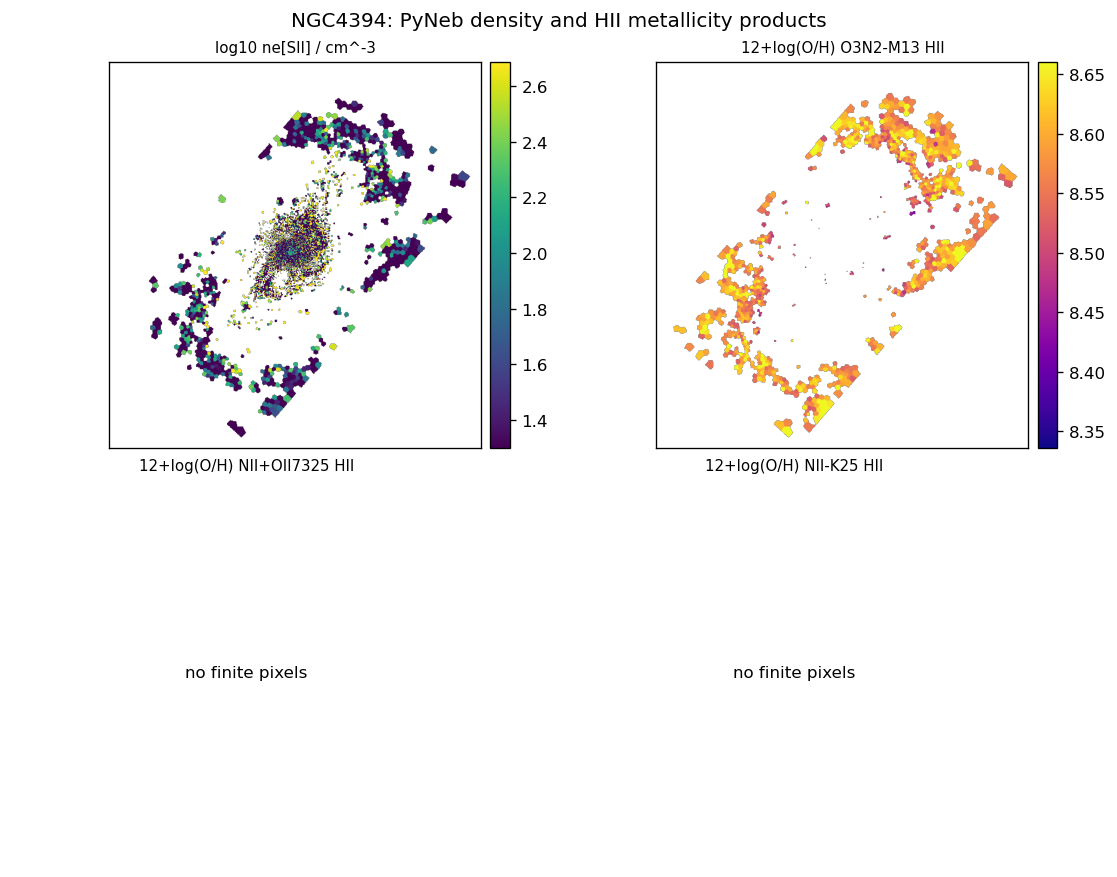

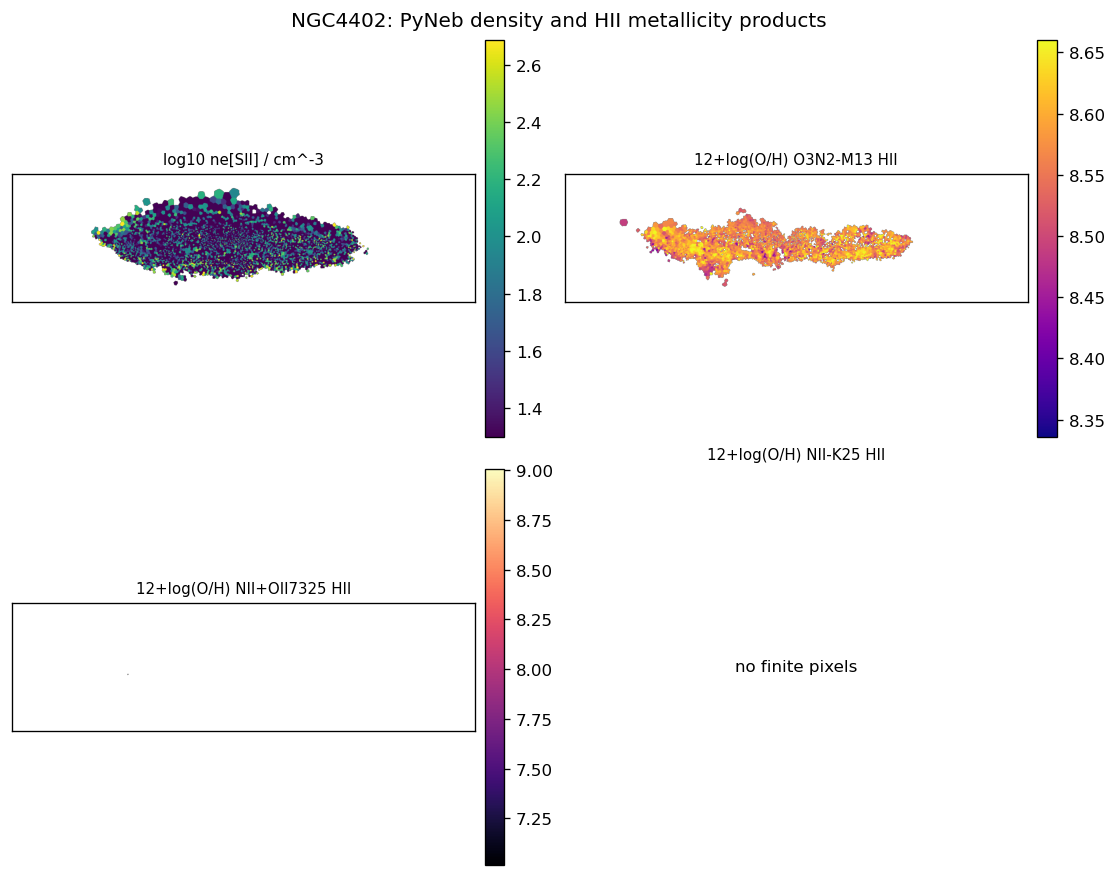

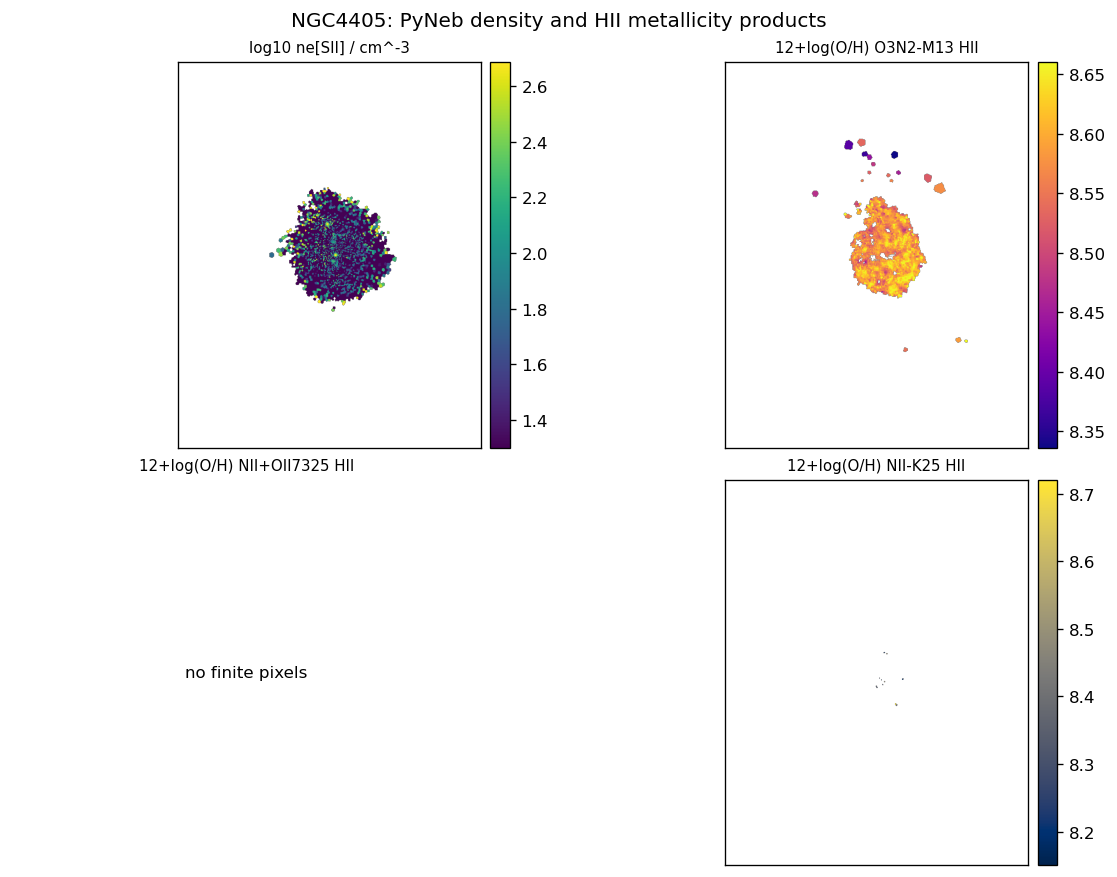

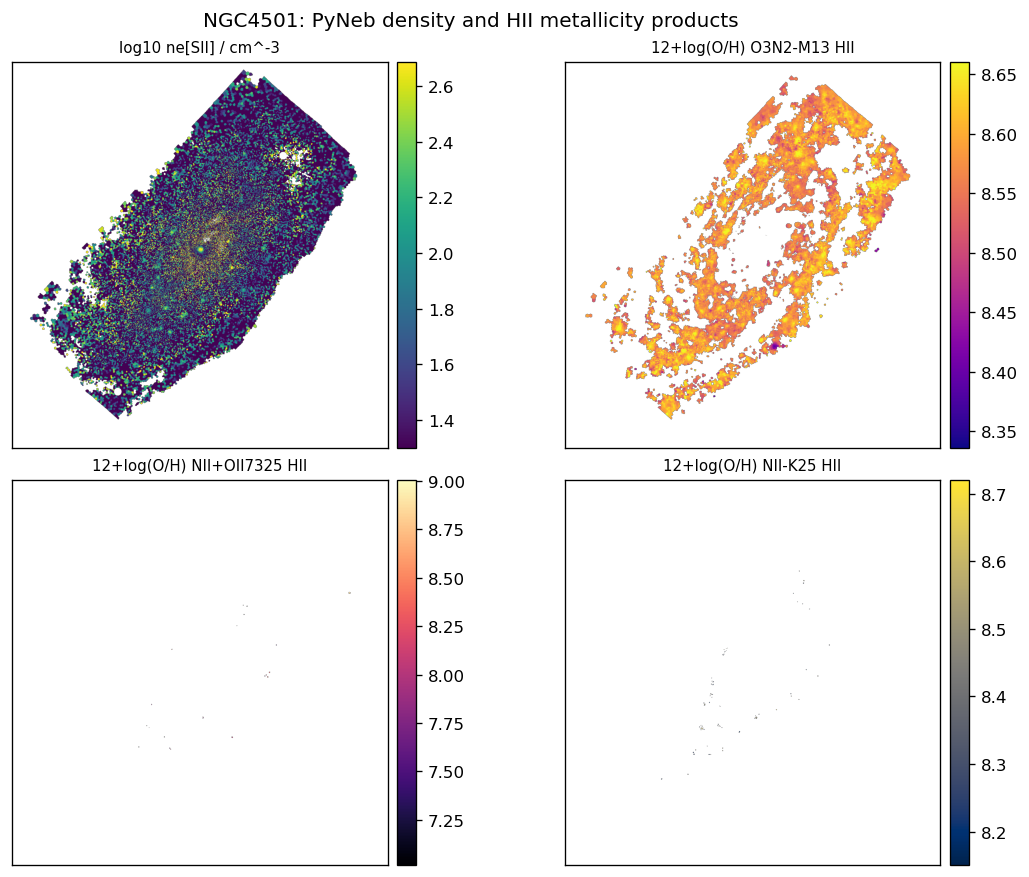

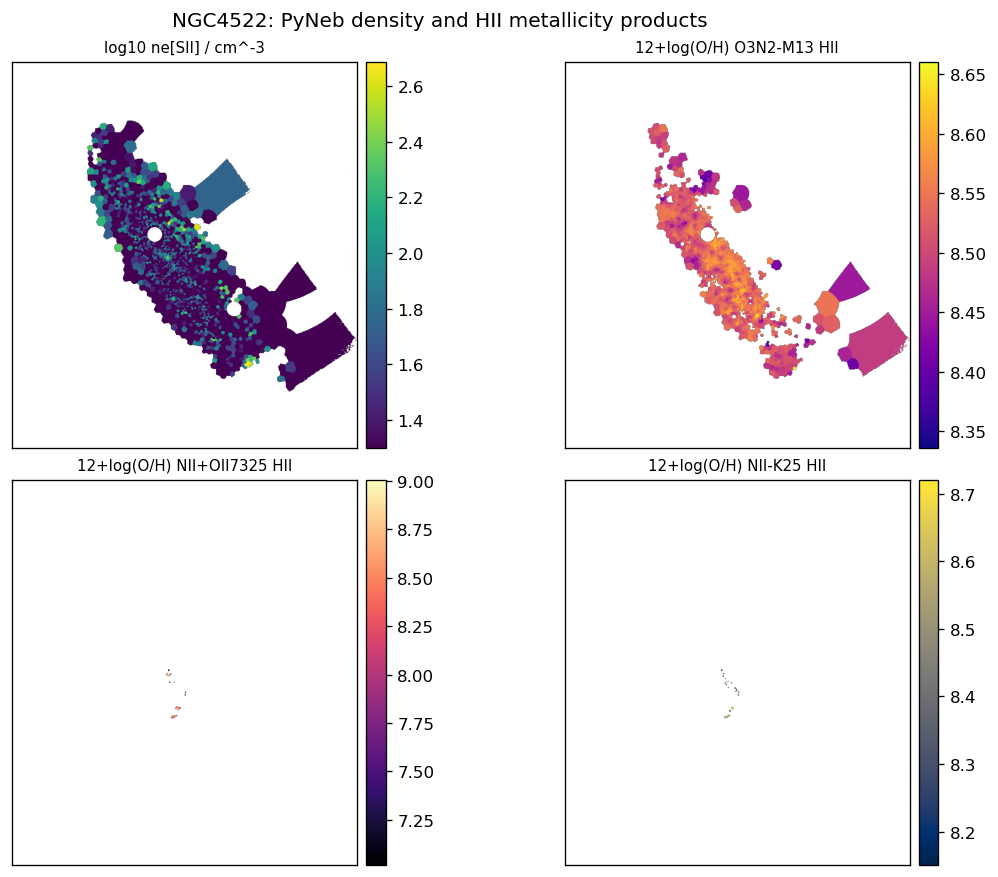

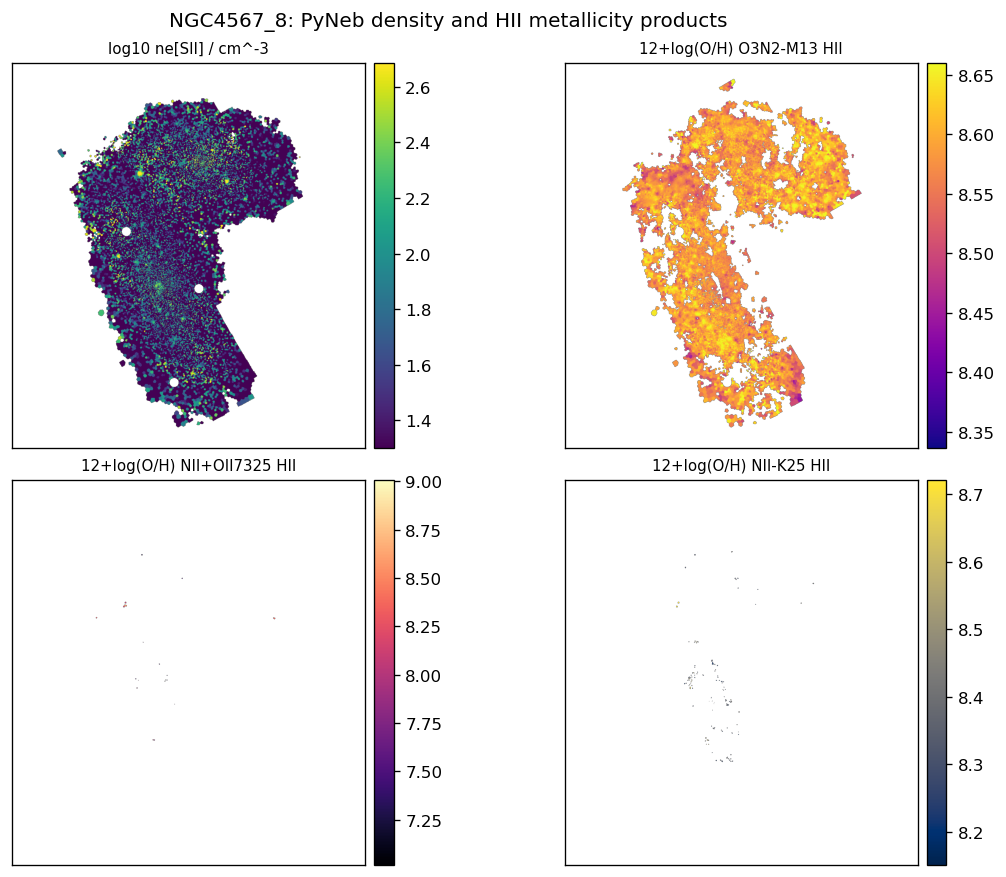

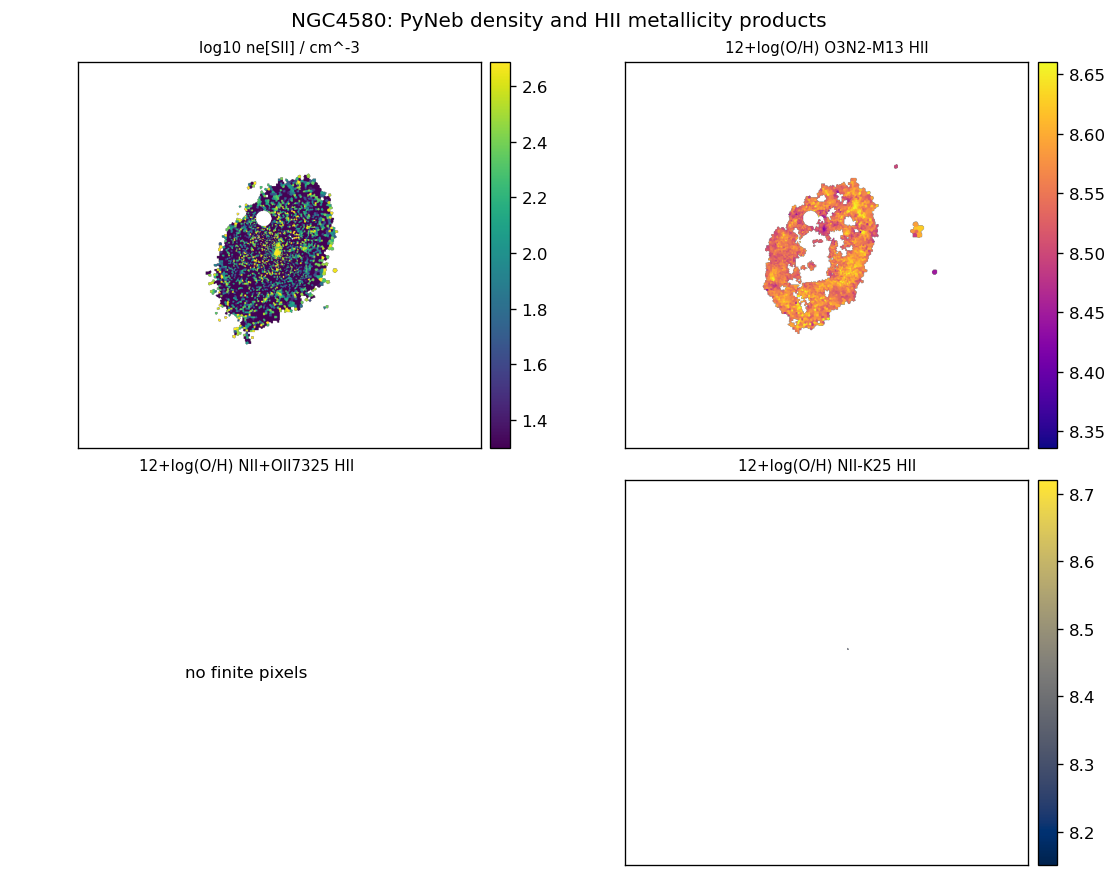

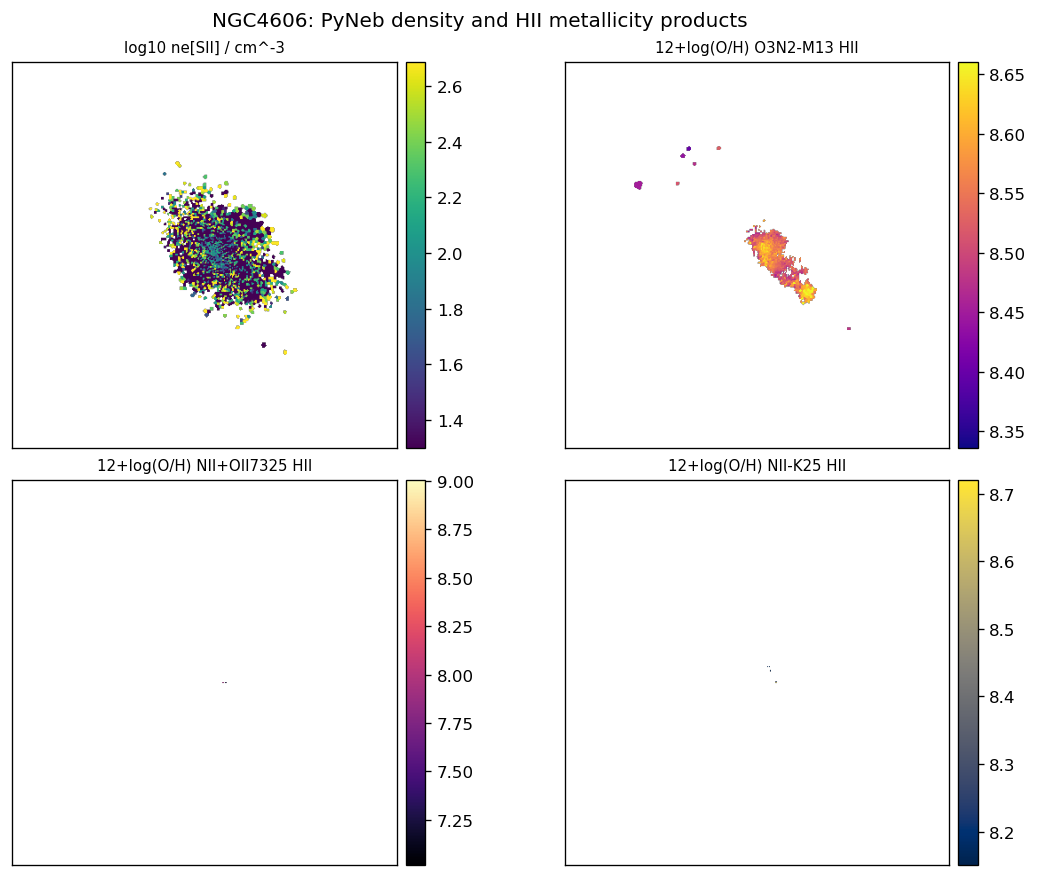

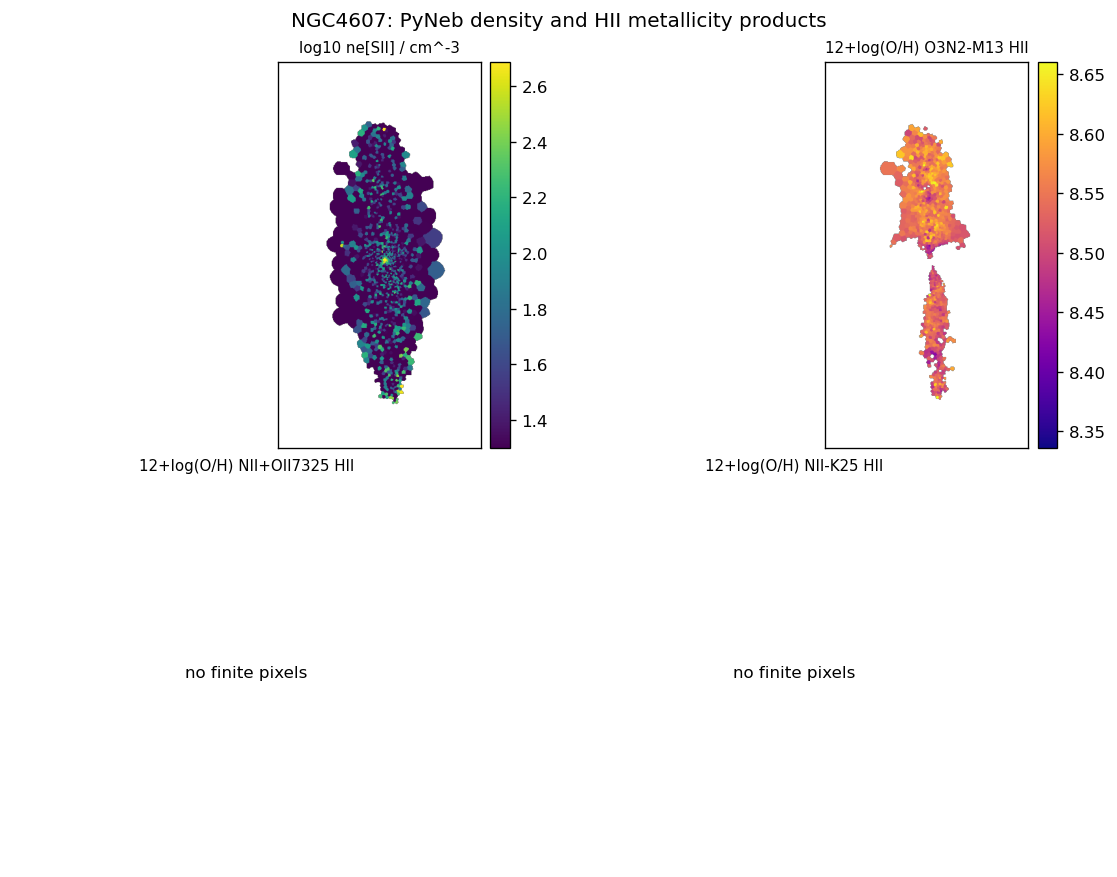

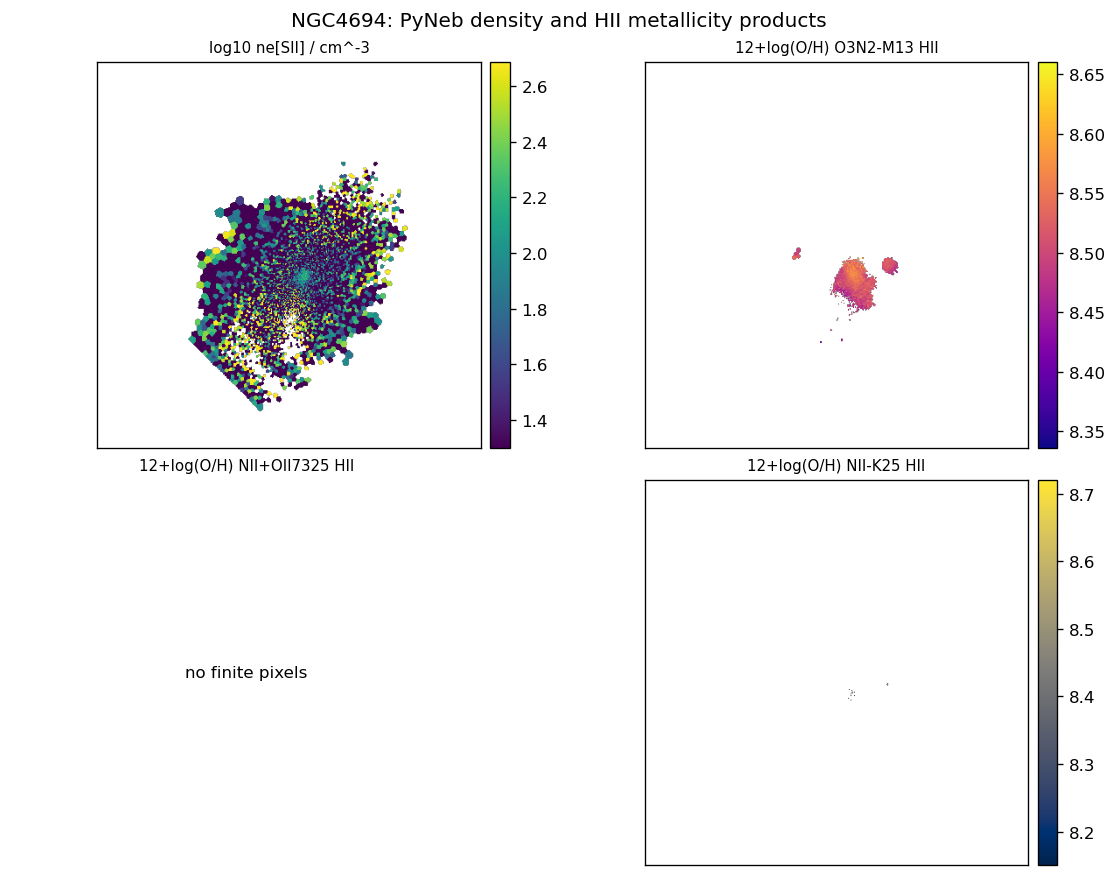

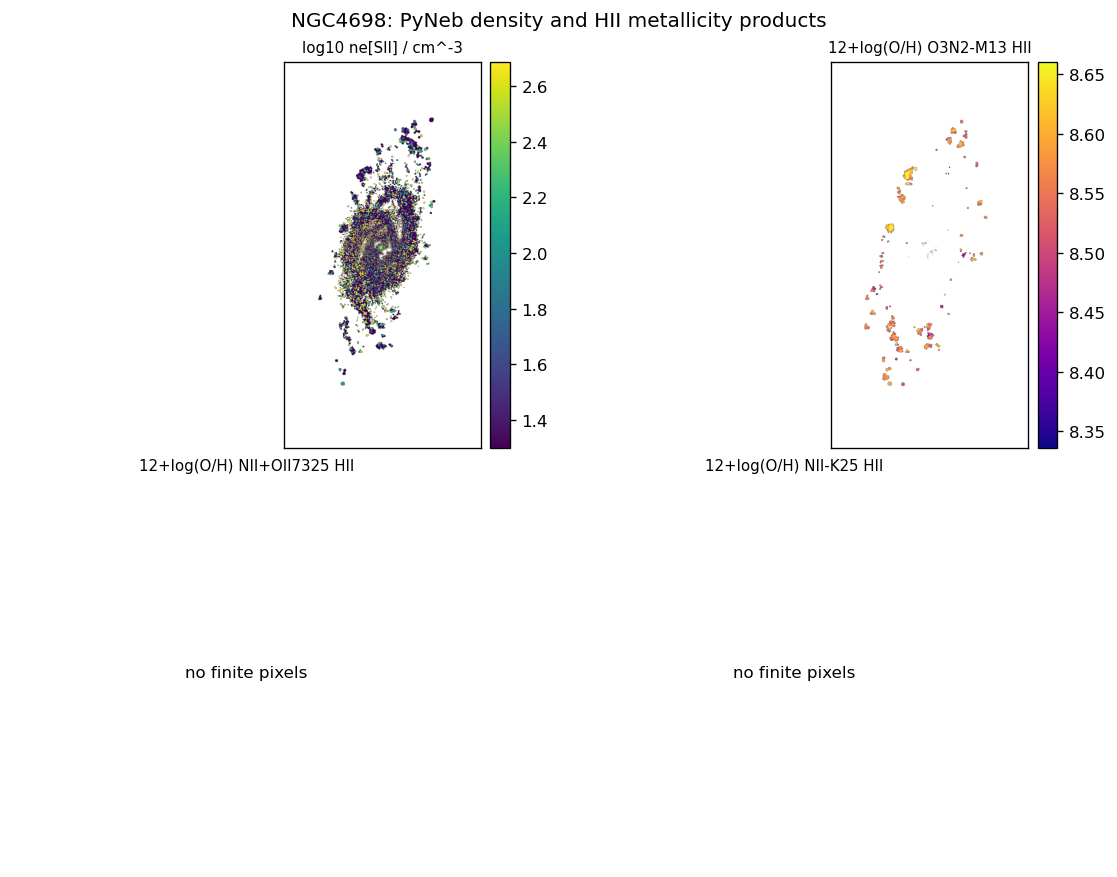

Created 18 Te-metallicity 2x2 figures.


In [5]:

def plot_te_metallicity_2x2(galaxy: str, *, display_limits: dict[str, tuple[float | None, float | None]] = DISPLAY_LIMITS):
    gas_path = PRODUCTS.loc[galaxy, "gas_path"]
    fig, axes = plt.subplots(2, 2, figsize=(9.2, 7.2), constrained_layout=True)
    axes = axes.ravel()

    for ax, spec in zip(axes, TARGET_MAP_SPECS):
        data = read_hdu(gas_path, spec["hdu"], dtype=float, required=False)
        display_data = display_transform(data, spec["transform"])
        vals = finite_values(display_data)
        if vals.size == 0:
            ax.text(0.5, 0.5, "no finite pixels", ha="center", va="center", transform=ax.transAxes)
            ax.set_title(spec["label"], fontsize=9)
            ax.set_axis_off()
            continue

        vmin, vmax = display_limits.get(spec["hdu"], (None, None))
        im = ax.imshow(display_data, origin="lower", cmap=spec["cmap"], vmin=vmin, vmax=vmax)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(spec["label"], fontsize=9)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)

    fig.suptitle(f"{galaxy}: PyNeb density and HII metallicity products", fontsize=12)
    # fig.savefig(OUTDIR / f"{galaxy}_te_metallicity_2x2.png", dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    return fig


print(f"Making Te-metallicity 2x2 figures for {len(AVAILABLE_GALAXIES)} galaxies.")
for gal in AVAILABLE_GALAXIES:
    plot_te_metallicity_2x2(gal)
print(f"Created {len(AVAILABLE_GALAXIES)} Te-metallicity 2x2 figures.")


Direct-method 2x2 axis limits: O/H=(7.242310036168072, 8.904731410863441), residual=(-1.340416798666844, 1.340416798666844), NE_SII color=(20.0, 240.24359155518732)
Total plotted direct-method spaxels: 6,796


,comparison_hdu,comparison_short_label,plotted_spaxels
0,O_H_NII_K25_HII,NII-K25,3487
1,O_H_NII_OII7325_HII,NII+OII7325,3309


comparison_short_label,NII+OII7325,NII-K25
galaxy,,
IC3392,11,0
NGC4064,2,212
NGC4189,279,56
NGC4192,718,517
NGC4294,1654,1347
NGC4351,195,177
NGC4402,5,0
NGC4405,0,45
NGC4501,158,371


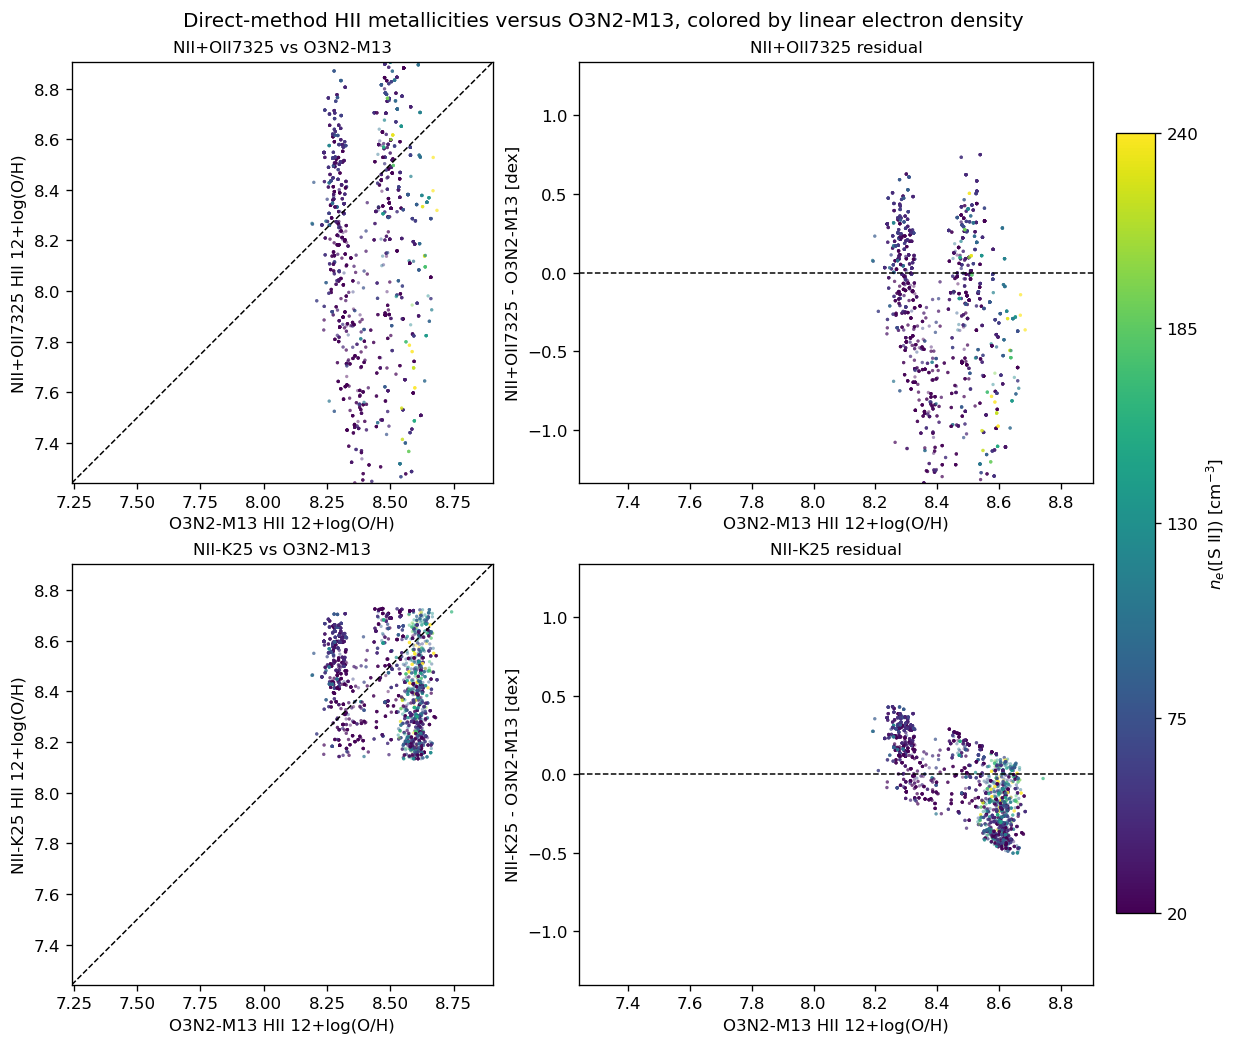

In [6]:

DIRECT_METHOD_COMPARISON_SPECS = [
    {
        "hdu": "O_H_NII_OII7325_HII",
        "label": "NII+OII7325 HII",
        "short_label": "NII+OII7325",
    },
    {
        "hdu": "O_H_NII_K25_HII",
        "label": "NII-K25 HII",
        "short_label": "NII-K25",
    },
]


def collect_direct_method_comparison_points(galaxies: list[str] = AVAILABLE_GALAXIES) -> pd.DataFrame:
    rows = []
    for gal in galaxies:
        gas_path = PRODUCTS.loc[gal, "gas_path"]
        reference = read_hdu(gas_path, "O_H_O3N2_M13_HII", dtype=float, required=False)
        ne_sii = read_hdu(gas_path, "NE_SII", dtype=float, required=False)
        if reference is None or ne_sii is None:
            continue
        ne_sii = align_map_to_shape(ne_sii, reference.shape, label=f"{gal} NE_SII")

        for spec in DIRECT_METHOD_COMPARISON_SPECS:
            comparison = read_hdu(gas_path, spec["hdu"], dtype=float, required=False)
            if comparison is None:
                continue
            comparison = align_map_to_shape(comparison, reference.shape, label=f"{gal} {spec['hdu']}")
            residual = comparison - reference
            ok = (
                np.isfinite(reference) &
                np.isfinite(comparison) &
                np.isfinite(residual) &
                np.isfinite(ne_sii) &
                (ne_sii > 0)
            )
            if not np.any(ok):
                continue
            rows.append(pd.DataFrame({
                "galaxy": gal,
                "comparison_hdu": spec["hdu"],
                "comparison_label": spec["label"],
                "comparison_short_label": spec["short_label"],
                "o3n2_m13_hii": reference[ok],
                "comparison_oh": comparison[ok],
                "residual_vs_o3n2": residual[ok],
                "ne_sii_linear": ne_sii[ok],
            }))
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()


def plot_direct_method_ne_comparison_2x2(points: pd.DataFrame):
    if points.empty:
        print("No finite overlapping direct-method pixels for the requested 2x2 comparison.")
        return None

    metallicity_values = np.concatenate([
        points["o3n2_m13_hii"].to_numpy(dtype=float),
        points["comparison_oh"].to_numpy(dtype=float),
    ])
    xylim = robust_limits_from_values(metallicity_values, qlo=1, qhi=99)
    residual_lim_abs = np.nanpercentile(np.abs(points["residual_vs_o3n2"].to_numpy(dtype=float)), 99)
    if not np.isfinite(residual_lim_abs) or residual_lim_abs == 0:
        residual_lim_abs = 0.1
    residual_limits = (-float(residual_lim_abs), float(residual_lim_abs))
    clim = robust_limits_from_values(points["ne_sii_linear"].to_numpy(dtype=float), qlo=1, qhi=99)
    ne_ticks = np.linspace(clim[0], clim[1], 5)

    DIRECT_METHOD_COUNTS = (
        points.groupby(["comparison_hdu", "comparison_short_label", "galaxy"])
        .size()
        .rename("plotted_spaxels")
        .reset_index()
    )
    method_totals = (
        DIRECT_METHOD_COUNTS.groupby(["comparison_hdu", "comparison_short_label"])["plotted_spaxels"]
        .sum()
        .reset_index()
    )
    print(f"Direct-method 2x2 axis limits: O/H={xylim}, residual={residual_limits}, NE_SII color={clim}")
    print(f"Total plotted direct-method spaxels: {int(method_totals['plotted_spaxels'].sum()):,}")
    display(method_totals)
    display(DIRECT_METHOD_COUNTS.pivot(index="galaxy", columns="comparison_short_label", values="plotted_spaxels").fillna(0).astype(int))

    cmap = plt.get_cmap("viridis")
    norm = mpl.colors.Normalize(vmin=clim[0], vmax=clim[1])
    fig, axes = plt.subplots(2, 2, figsize=(10.5, 8.6), constrained_layout=True)

    for row, spec in enumerate(DIRECT_METHOD_COMPARISON_SPECS):
        sub = points[points["comparison_hdu"] == spec["hdu"]]
        pair_ax = axes[row, 0]
        resid_ax = axes[row, 1]
        if sub.empty:
            for ax in (pair_ax, resid_ax):
                ax.text(0.5, 0.5, "no finite overlap", ha="center", va="center", transform=ax.transAxes)
                ax.set_axis_off()
            continue

        pair_ax.scatter(
            sub["o3n2_m13_hii"],
            sub["comparison_oh"],
            c=sub["ne_sii_linear"],
            s=4,
            alpha=0.45,
            cmap=cmap,
            norm=norm,
            linewidths=0,
            rasterized=True,
        )
        pair_ax.plot(xylim, xylim, ls="--", color="black", lw=0.9)
        pair_ax.set_xlim(xylim)
        pair_ax.set_ylim(xylim)
        pair_ax.set_aspect("equal", adjustable="box")
        pair_ax.set_xlabel("O3N2-M13 HII 12+log(O/H)")
        pair_ax.set_ylabel(f"{spec['short_label']} HII 12+log(O/H)")
        pair_ax.set_title(f"{spec['short_label']} vs O3N2-M13", fontsize=10)

        resid_ax.scatter(
            sub["o3n2_m13_hii"],
            sub["residual_vs_o3n2"],
            c=sub["ne_sii_linear"],
            s=4,
            alpha=0.45,
            cmap=cmap,
            norm=norm,
            linewidths=0,
            rasterized=True,
        )
        resid_ax.axhline(0, ls="--", color="black", lw=0.9)
        resid_ax.set_xlim(xylim)
        resid_ax.set_ylim(residual_limits)
        resid_ax.set_xlabel("O3N2-M13 HII 12+log(O/H)")
        resid_ax.set_ylabel(f"{spec['short_label']} - O3N2-M13 [dex]")
        resid_ax.set_title(f"{spec['short_label']} residual", fontsize=10)

    mappable = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    cb = fig.colorbar(mappable, ax=axes.ravel().tolist(), fraction=0.035, pad=0.02, ticks=ne_ticks)
    cb.set_label(r"$n_e$([S II]) [cm$^{-3}$]")
    cb.ax.set_yticklabels([f"{tick:.0f}" for tick in ne_ticks])
    fig.suptitle("Direct-method HII metallicities versus O3N2-M13, colored by linear electron density", fontsize=12)
    # fig.savefig(OUTDIR / "direct_method_o3n2_ne_2x2.png", dpi=220, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    return fig


DIRECT_METHOD_POINTS = collect_direct_method_comparison_points()
fig = plot_direct_method_ne_comparison_2x2(DIRECT_METHOD_POINTS)


Corner grid for LOGMASS_SURFACE_DENSITY: 18 galaxies, axis limits=(8.020477474185489, 8.950945715031063), color limits=(6.255555477700696, 9.02881403909931)
Metallicity values contributing to limits: 13,130,990; color values: 1,091,922
Total plotted lower-triangle spaxel-points: 6,565,495


x_label,D16,NII+OII7325,O3N2-C20,O3N2-M13,PG16
y_label,,,,,
D16,0,0,1089928,1089350,0
NII+OII7325,3306,0,3324,3309,3324
NII-K25,3499,2090,3502,3487,3502
O3N2-C20,0,0,0,1090973,0
PG16,1088312,0,1089102,1088487,0


,x_hdu,x_label,y_hdu,y_label,plotted_spaxels
0,O_H_O3N2_M13_HII,O3N2-M13,O_H_O3N2_C20_HII,O3N2-C20,1090973
1,O_H_O3N2_M13_HII,O3N2-M13,O_H_D16_HII,D16,1089350
2,O_H_O3N2_C20_HII,O3N2-C20,O_H_D16_HII,D16,1089928
3,O_H_O3N2_M13_HII,O3N2-M13,O_H_PG16_HII,PG16,1088487
4,O_H_O3N2_C20_HII,O3N2-C20,O_H_PG16_HII,PG16,1089102
5,O_H_D16_HII,D16,O_H_PG16_HII,PG16,1088312
6,O_H_O3N2_M13_HII,O3N2-M13,O_H_NII_OII7325_HII,NII+OII7325,3309
7,O_H_O3N2_C20_HII,O3N2-C20,O_H_NII_OII7325_HII,NII+OII7325,3324
8,O_H_D16_HII,D16,O_H_NII_OII7325_HII,NII+OII7325,3306
9,O_H_PG16_HII,PG16,O_H_NII_OII7325_HII,NII+OII7325,3324


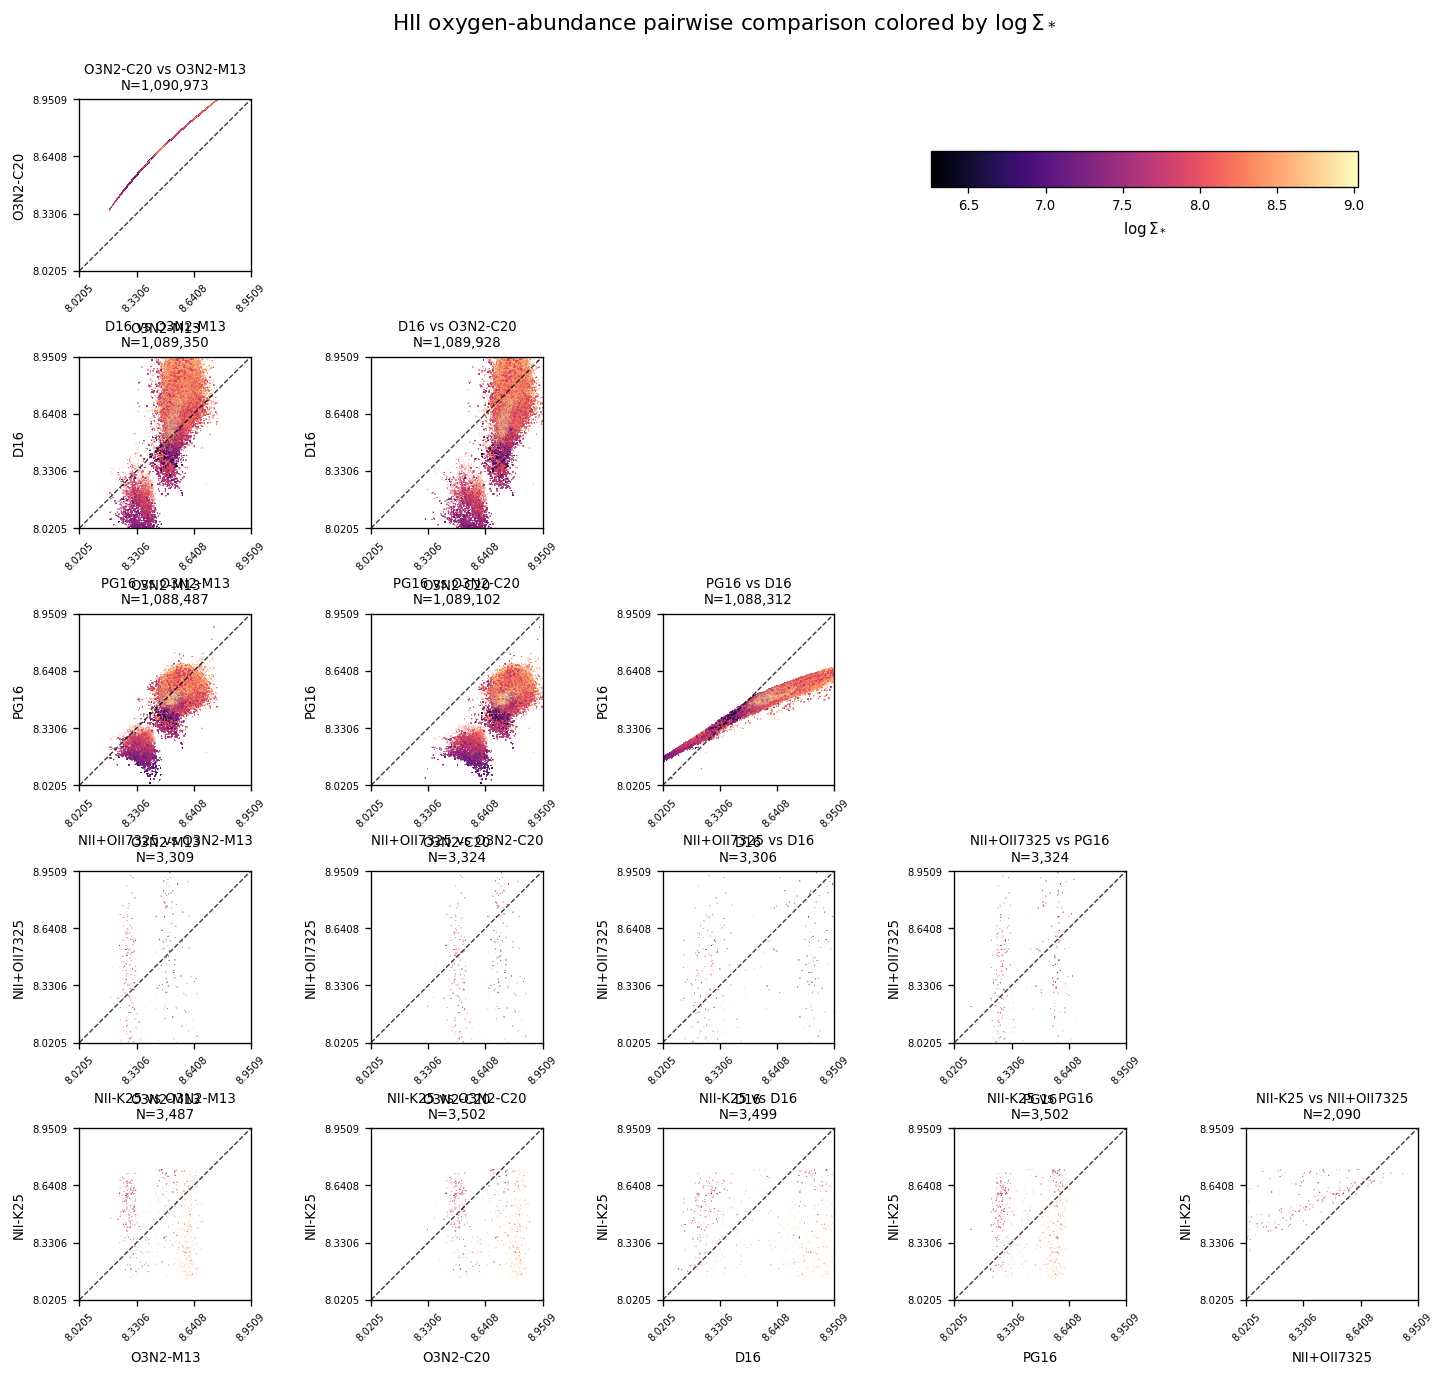

In [7]:

METALLICITY_PAIR_SPECS = [
    ("O_H_O3N2_M13_HII", "O3N2-M13"),
    ("O_H_O3N2_C20_HII", "O3N2-C20"),
    ("O_H_D16_HII", "D16"),
    ("O_H_PG16_HII", "PG16"),
    ("O_H_NII_OII7325_HII", "NII+OII7325"),
    ("O_H_NII_K25_HII", "NII-K25"),
]
METALLICITY_PAIR_HDUS = [hdu for hdu, _ in METALLICITY_PAIR_SPECS]

COLOR_QUANTITY_SPECS = {
    "LOGMASS_SURFACE_DENSITY": {
        "path_kind": "spatial",
        "label": r"$\log\Sigma_*$",
        "cmap": "magma",
        "filename": "metallicity_corner_by_logmass.png",
    },
    "LOGSFR_SURFACE_DENSITY_HII": {
        "path_kind": "gas",
        "label": r"$\log\Sigma_{SFR}$ HII",
        "cmap": "viridis",
        "filename": "metallicity_corner_by_logsfr_hii.png",
    },
}


def read_corner_maps(galaxy: str, *, color_quantity: str) -> dict[str, np.ndarray] | None:
    gas_path = PRODUCTS.loc[galaxy, "gas_path"]
    color_spec = COLOR_QUANTITY_SPECS[color_quantity]
    color_path = PRODUCTS.loc[galaxy, "spatial_path"] if color_spec["path_kind"] == "spatial" else gas_path
    if color_path is None:
        return None

    maps = {}
    reference_shape = None
    for hdu_name, _ in METALLICITY_PAIR_SPECS:
        data = read_hdu(gas_path, hdu_name, dtype=float, required=False)
        if data is None:
            return None
        if reference_shape is None:
            reference_shape = data.shape
        maps[hdu_name] = align_map_to_shape(data, reference_shape, label=f"{galaxy} {hdu_name}")

    color_data = read_hdu(color_path, color_quantity, dtype=float, required=False)
    if color_data is None or reference_shape is None:
        return None
    maps[color_quantity] = align_map_to_shape(color_data, reference_shape, label=f"{galaxy} {color_quantity}")
    return maps


def prepare_corner_payload(color_quantity: str, galaxies: list[str] = AVAILABLE_GALAXIES):
    payload = []
    for gal in galaxies:
        maps = read_corner_maps(gal, color_quantity=color_quantity)
        if maps is not None:
            payload.append({"galaxy": gal, "maps": maps})
    return payload


def corner_limits_from_payload(payload: list[dict], color_quantity: str):
    metallicity_values = []
    color_values = []
    for item in payload:
        maps = item["maps"]
        color = maps[color_quantity]
        any_pair_ok = np.zeros(color.shape, dtype=bool)
        for y_idx in range(1, len(METALLICITY_PAIR_SPECS)):
            y_hdu = METALLICITY_PAIR_SPECS[y_idx][0]
            for x_idx in range(y_idx):
                x_hdu = METALLICITY_PAIR_SPECS[x_idx][0]
                ok = np.isfinite(maps[x_hdu]) & np.isfinite(maps[y_hdu]) & np.isfinite(color)
                any_pair_ok |= ok
                if np.any(ok):
                    metallicity_values.append(maps[x_hdu][ok])
                    metallicity_values.append(maps[y_hdu][ok])
        if np.any(any_pair_ok):
            color_values.append(color[any_pair_ok])

    metallicity_values = np.concatenate(metallicity_values) if metallicity_values else np.array([], dtype=float)
    color_values = np.concatenate(color_values) if color_values else np.array([], dtype=float)
    xylim = robust_limits_from_values(metallicity_values, qlo=0.5, qhi=99.5)
    clim = robust_limits_from_values(color_values, qlo=1, qhi=99)
    return xylim, clim, metallicity_values.size, color_values.size


def plot_metallicity_corner_grid(
    *,
    color_quantity: str,
    galaxies: list[str] = AVAILABLE_GALAXIES,
    point_size: float = 0.35,
    point_alpha: float = 0.18,
):
    color_spec = COLOR_QUANTITY_SPECS[color_quantity]
    payload = prepare_corner_payload(color_quantity, galaxies)
    if not payload:
        print(f"No galaxies have all corner-plot HDUs plus {color_quantity}.")
        return None

    xylim, clim, metallicity_value_count, color_value_count = corner_limits_from_payload(payload, color_quantity)
    if xylim == (None, None) or clim == (None, None):
        print(f"No finite pairwise HII metallicity points with {color_quantity}.")
        return None

    n_methods = len(METALLICITY_PAIR_SPECS)
    n_compare = len(METALLICITY_PAIR_SPECS) - 1
    tick_values = np.linspace(xylim[0], xylim[1], 4)
    cmap = plt.get_cmap(color_spec["cmap"])
    norm = mpl.colors.Normalize(vmin=clim[0], vmax=clim[1])
    mappable = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)

    fig, axes = plt.subplots(n_compare, n_compare, figsize=(13.2, 12.2), sharex=False, sharey=False)
    count_rows = []
    total_plotted = 0

    for row_pos, y_idx in enumerate(range(1, n_methods)):
        y_hdu, y_label = METALLICITY_PAIR_SPECS[y_idx]
        for col_pos, x_idx in enumerate(range(0, n_methods - 1)):
            x_hdu, x_label = METALLICITY_PAIR_SPECS[x_idx]
            ax = axes[row_pos, col_pos]
            if x_idx >= y_idx:
                ax.set_axis_off()
                continue

            subplot_count = 0
            for item in payload:
                maps = item["maps"]
                color = maps[color_quantity]
                ok = np.isfinite(maps[x_hdu]) & np.isfinite(maps[y_hdu]) & np.isfinite(color)
                if not np.any(ok):
                    continue
                ax.scatter(
                    maps[x_hdu][ok],
                    maps[y_hdu][ok],
                    c=color[ok],
                    s=point_size,
                    alpha=point_alpha,
                    cmap=cmap,
                    norm=norm,
                    linewidths=0,
                    rasterized=True,
                )
                subplot_count += int(np.count_nonzero(ok))

            total_plotted += subplot_count
            count_rows.append({
                "x_hdu": x_hdu,
                "x_label": x_label,
                "y_hdu": y_hdu,
                "y_label": y_label,
                "plotted_spaxels": subplot_count,
            })
            ax.plot(xylim, xylim, ls="--", lw=0.8, color="black", alpha=0.8)
            ax.set_xlim(xylim)
            ax.set_ylim(xylim)
            ax.set_aspect("equal", adjustable="box")
            ax.set_xticks(tick_values)
            ax.set_yticks(tick_values)
            ax.tick_params(axis="both", which="major", labelsize=6, labelbottom=True, labelleft=True)
            ax.tick_params(axis="x", labelrotation=45)
            ax.set_xlabel(x_label, fontsize=8)
            ax.set_ylabel(y_label, fontsize=8)
            ax.set_title(f"{y_label} vs {x_label}\nN={subplot_count:,}", fontsize=8)

    PAIRWISE_COUNTS = pd.DataFrame(count_rows)
    print(
        f"Corner grid for {color_quantity}: {len(payload)} galaxies, "
        f"axis limits={xylim}, color limits={clim}"
    )
    print(f"Metallicity values contributing to limits: {metallicity_value_count:,}; color values: {color_value_count:,}")
    print(f"Total plotted lower-triangle spaxel-points: {total_plotted:,}")
    display(PAIRWISE_COUNTS.pivot(index="y_label", columns="x_label", values="plotted_spaxels").fillna(0).astype(int))
    display(PAIRWISE_COUNTS)

    fig.subplots_adjust(left=0.08, right=0.95, bottom=0.08, top=0.9, wspace=0.38, hspace=0.5)
    cax = fig.add_axes([0.63, 0.84, 0.27, 0.025])
    cb = fig.colorbar(mappable, cax=cax, orientation="horizontal")
    cb.set_label(color_spec["label"], fontsize=9)
    cb.ax.tick_params(labelsize=8)
    fig.suptitle(
        "HII oxygen-abundance pairwise comparison colored by " + color_spec["label"],
        fontsize=13,
        y=0.96,
    )
    # fig.savefig(OUTDIR / color_spec["filename"], dpi=220, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    return fig


fig = plot_metallicity_corner_grid(color_quantity="LOGMASS_SURFACE_DENSITY")


Corner grid for LOGSFR_SURFACE_DENSITY_HII: 18 galaxies, axis limits=(8.020477474185489, 8.950945715031063), color limits=(-3.5972052388994724, -0.6381970520386985)
Metallicity values contributing to limits: 13,131,242; color values: 1,091,943
Total plotted lower-triangle spaxel-points: 6,565,621


x_label,D16,NII+OII7325,O3N2-C20,O3N2-M13,PG16
y_label,,,,,
D16,0,0,1089949,1089371,0
NII+OII7325,3306,0,3324,3309,3324
NII-K25,3499,2090,3502,3487,3502
O3N2-C20,0,0,0,1090994,0
PG16,1088333,0,1089123,1088508,0


,x_hdu,x_label,y_hdu,y_label,plotted_spaxels
0,O_H_O3N2_M13_HII,O3N2-M13,O_H_O3N2_C20_HII,O3N2-C20,1090994
1,O_H_O3N2_M13_HII,O3N2-M13,O_H_D16_HII,D16,1089371
2,O_H_O3N2_C20_HII,O3N2-C20,O_H_D16_HII,D16,1089949
3,O_H_O3N2_M13_HII,O3N2-M13,O_H_PG16_HII,PG16,1088508
4,O_H_O3N2_C20_HII,O3N2-C20,O_H_PG16_HII,PG16,1089123
5,O_H_D16_HII,D16,O_H_PG16_HII,PG16,1088333
6,O_H_O3N2_M13_HII,O3N2-M13,O_H_NII_OII7325_HII,NII+OII7325,3309
7,O_H_O3N2_C20_HII,O3N2-C20,O_H_NII_OII7325_HII,NII+OII7325,3324
8,O_H_D16_HII,D16,O_H_NII_OII7325_HII,NII+OII7325,3306
9,O_H_PG16_HII,PG16,O_H_NII_OII7325_HII,NII+OII7325,3324


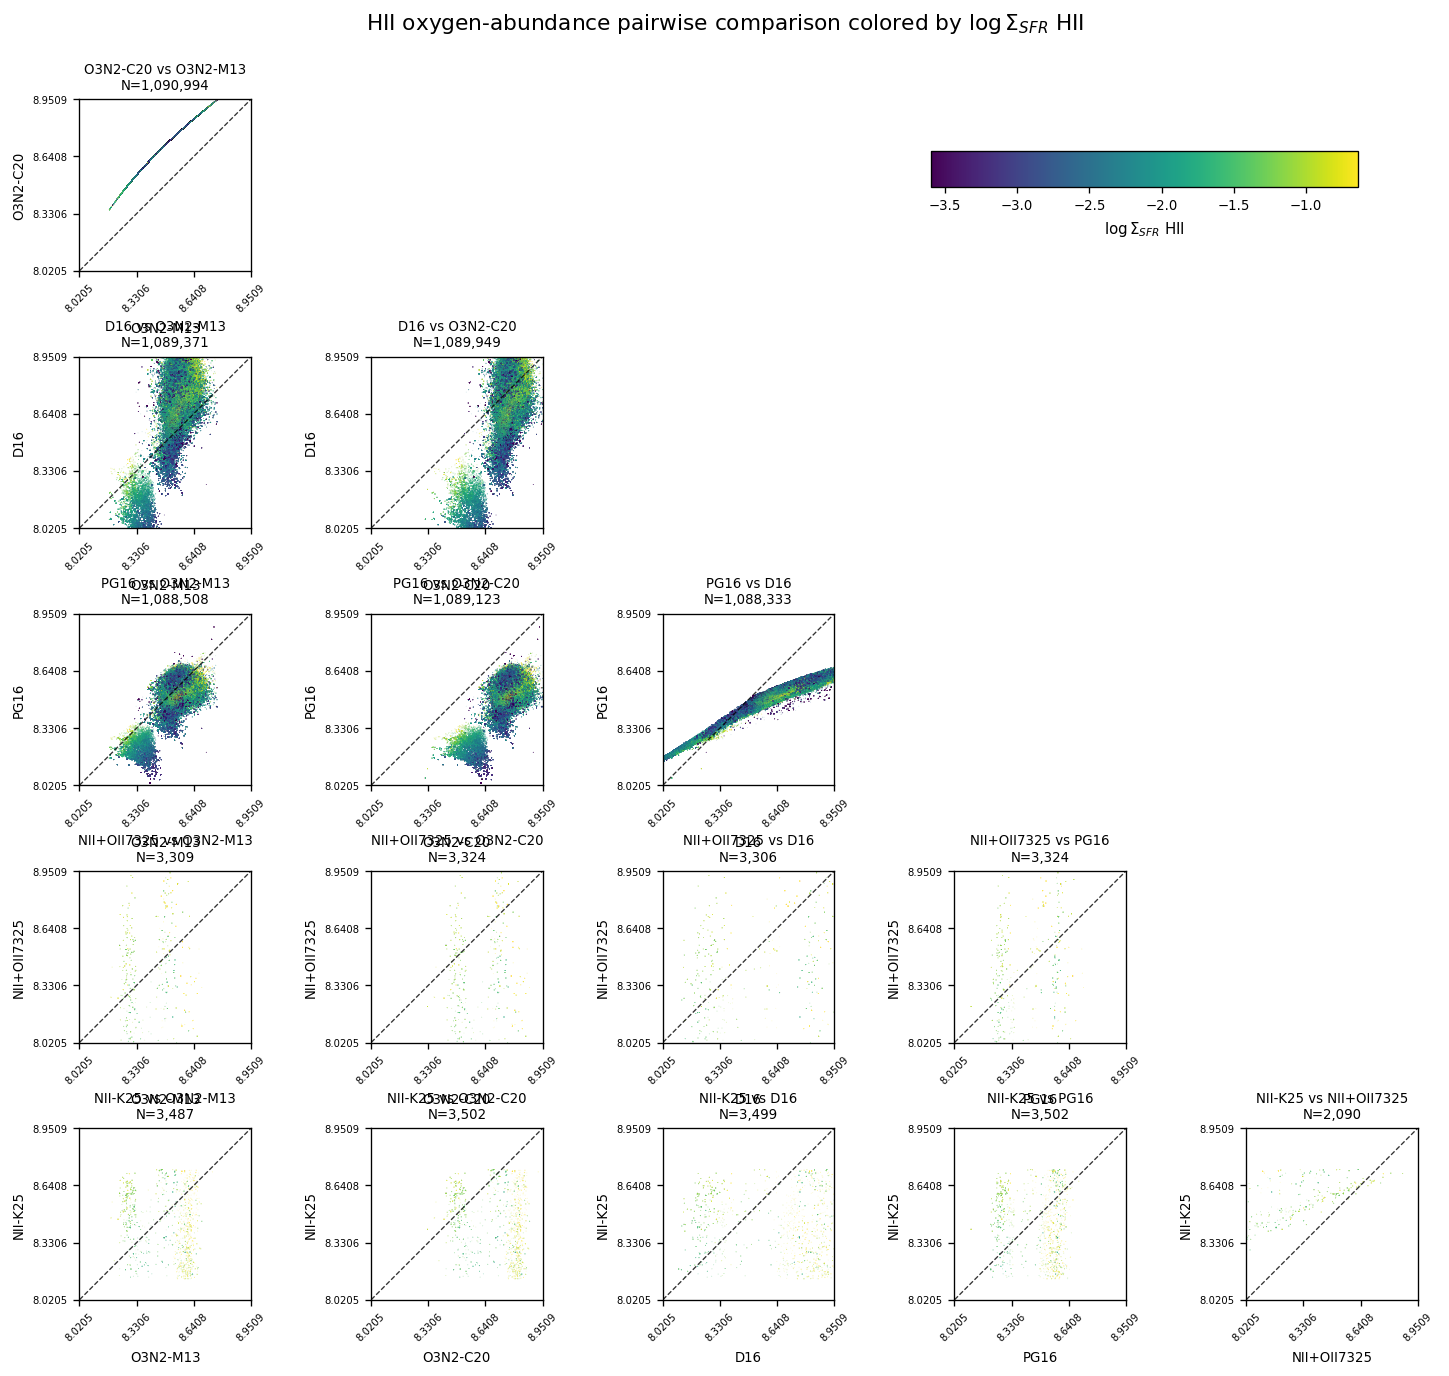

In [8]:
fig = plot_metallicity_corner_grid(color_quantity="LOGSFR_SURFACE_DENSITY_HII")


,ne_sii_finite,ne_sii_fixed20,fixed20_fraction,te_nii_hii_finite,nii_oii7325_valid_hii,nii_k25_valid_hii
galaxy,,,,,,
IC3392,22573,12537,0.5554,256,29,0
NGC4064,34546,17843,0.5165,566,2,212
NGC4189,135548,56890,0.4197,317,279,56
NGC4192,432021,205572,0.4758,1189,718,517
NGC4293,50685,23751,0.4686,11,0,0
NGC4294,132146,53826,0.4073,1771,1678,1362
NGC4351,51600,24325,0.4714,263,195,177
NGC4394,49814,22755,0.4568,0,0,0
NGC4402,94883,43163,0.4549,155,5,0


Making density/Te QC 2x2 figures for 18 galaxies.


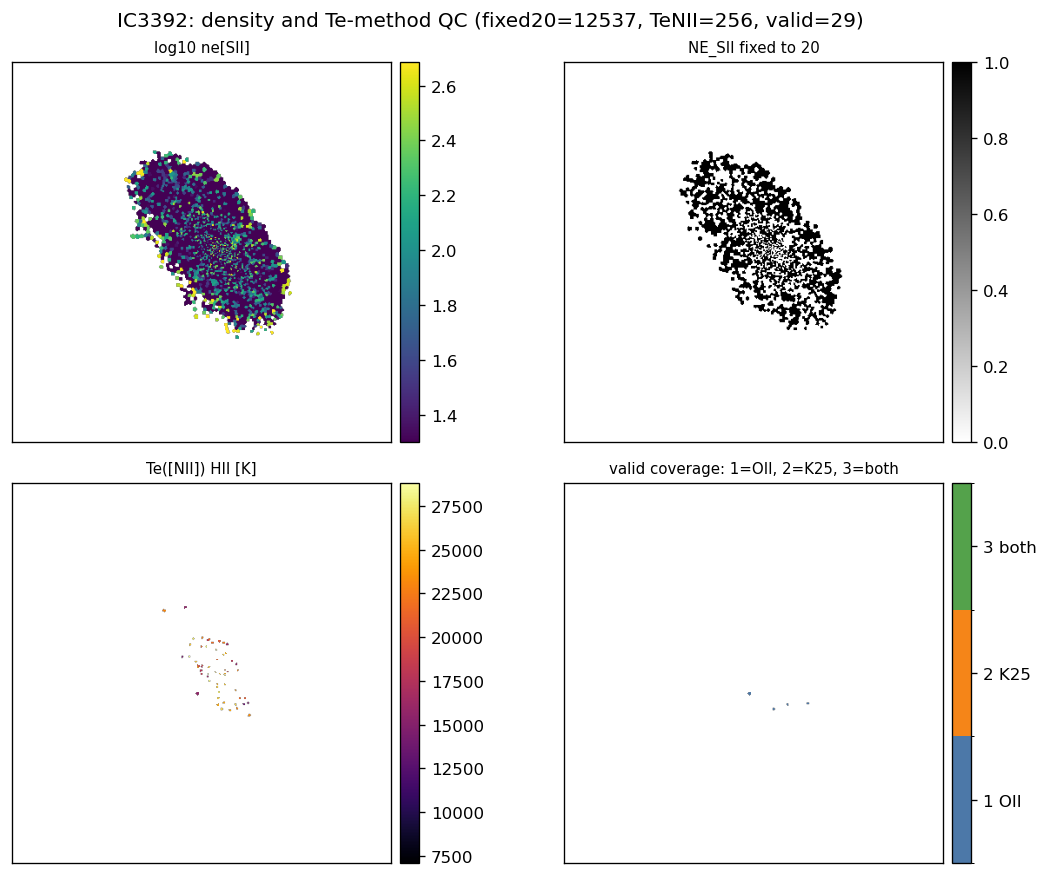

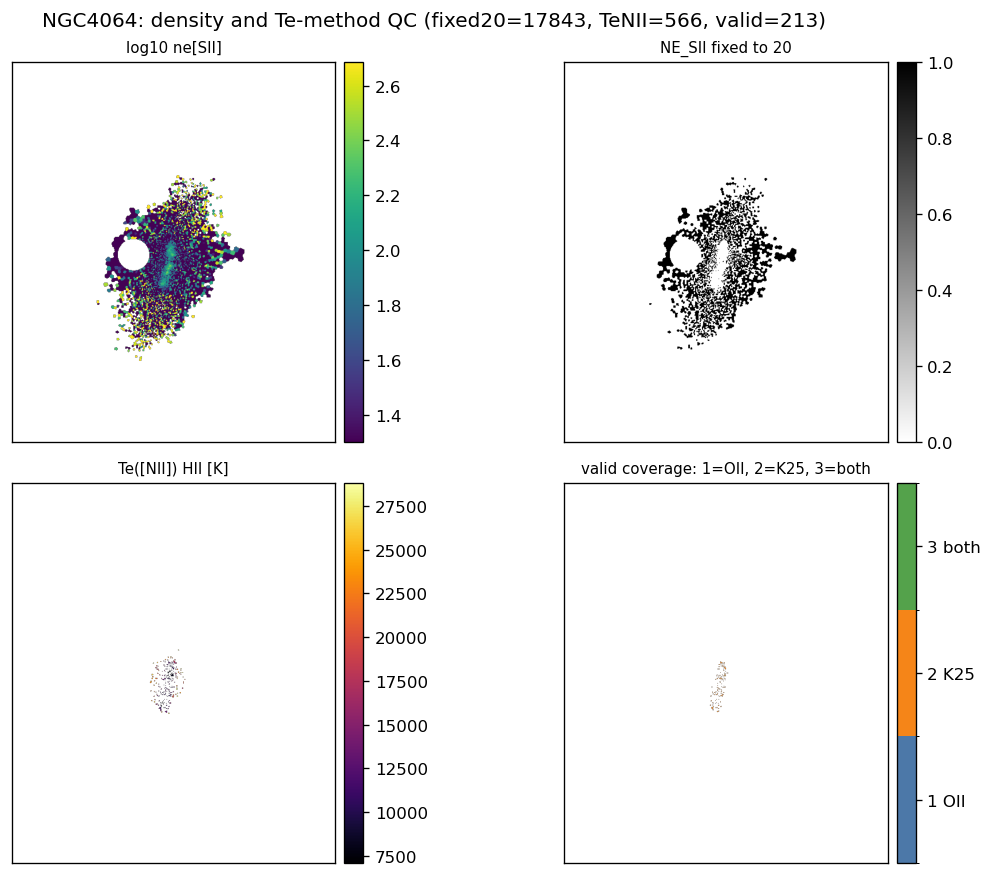

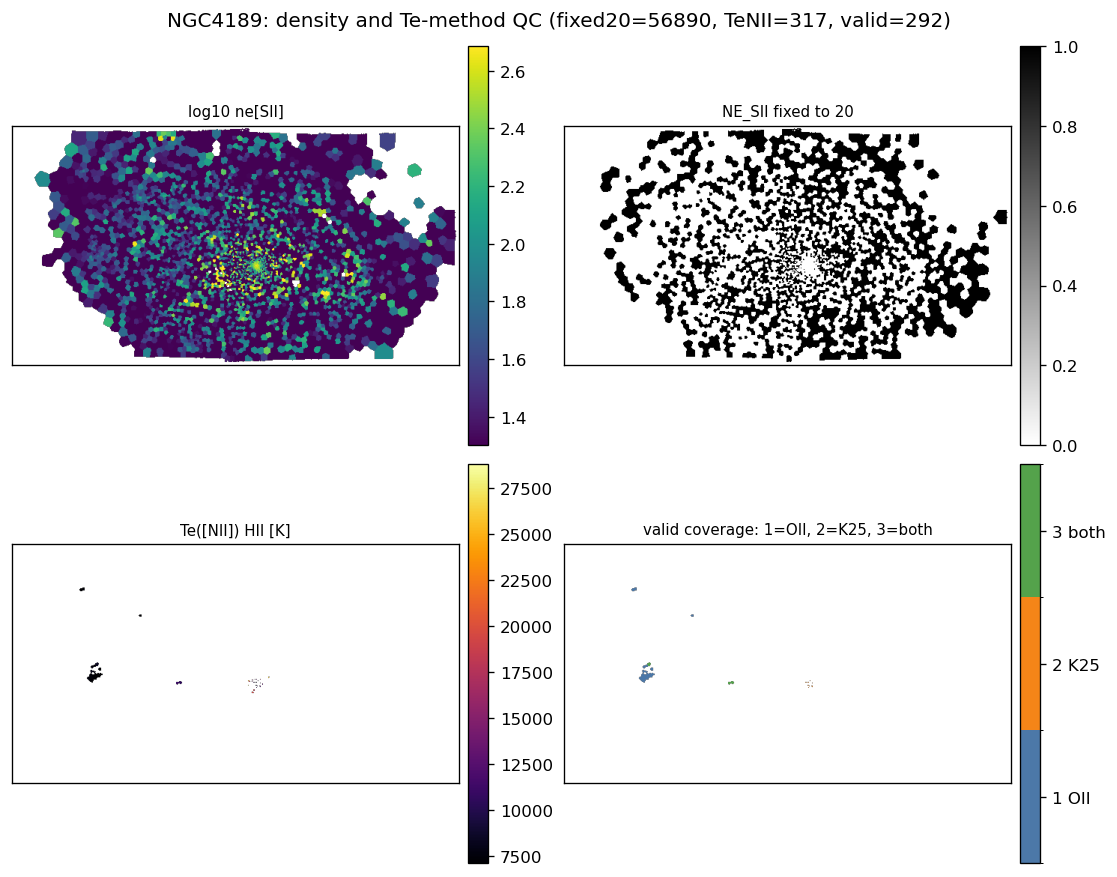

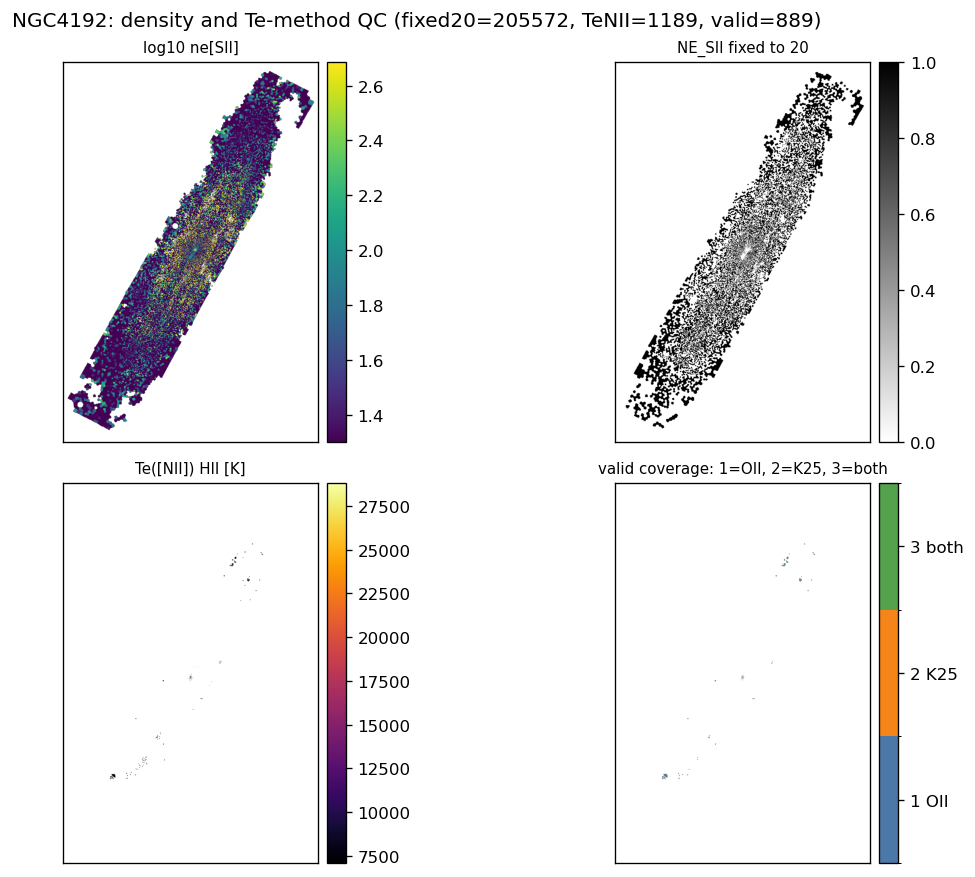

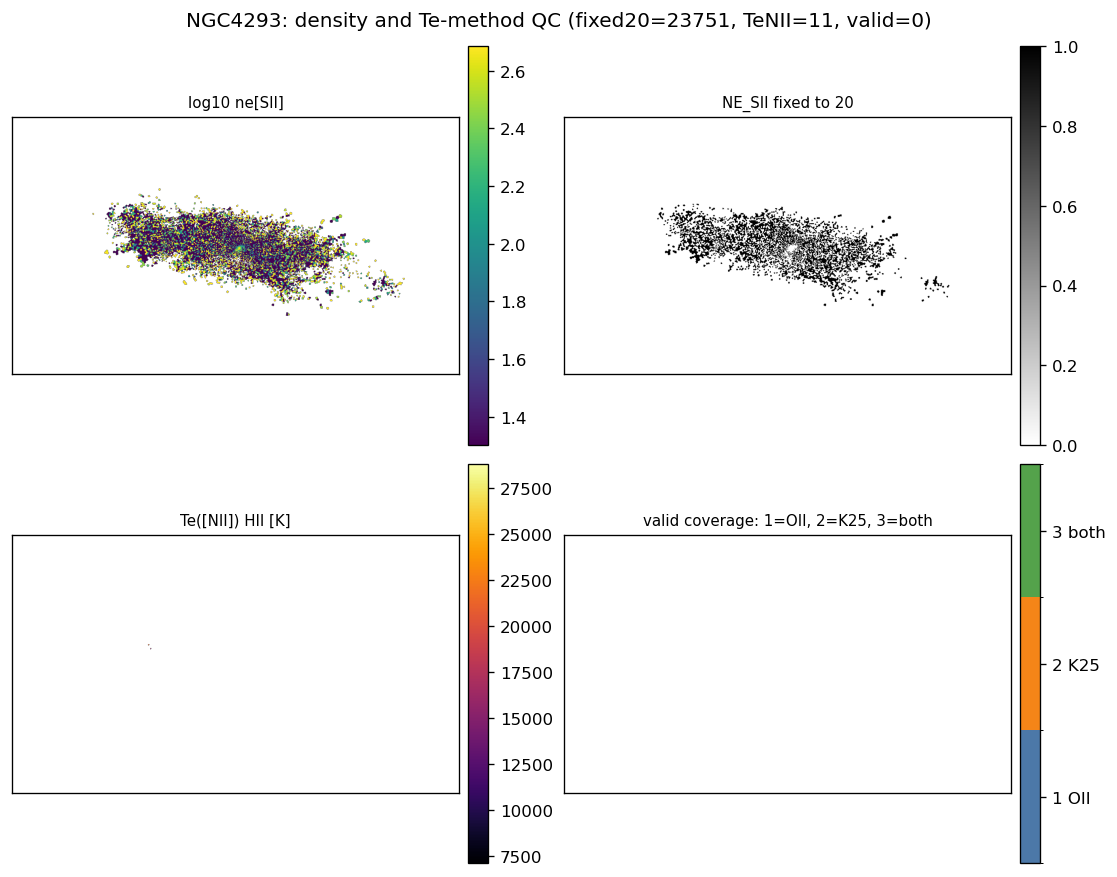

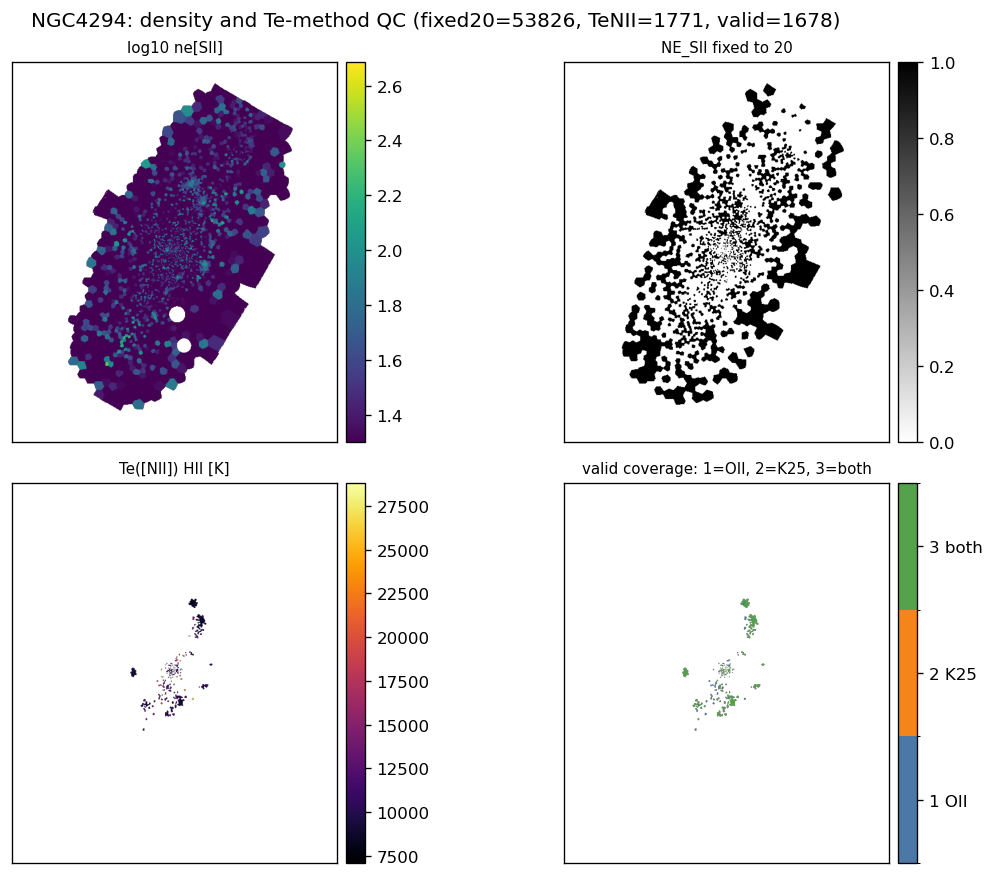

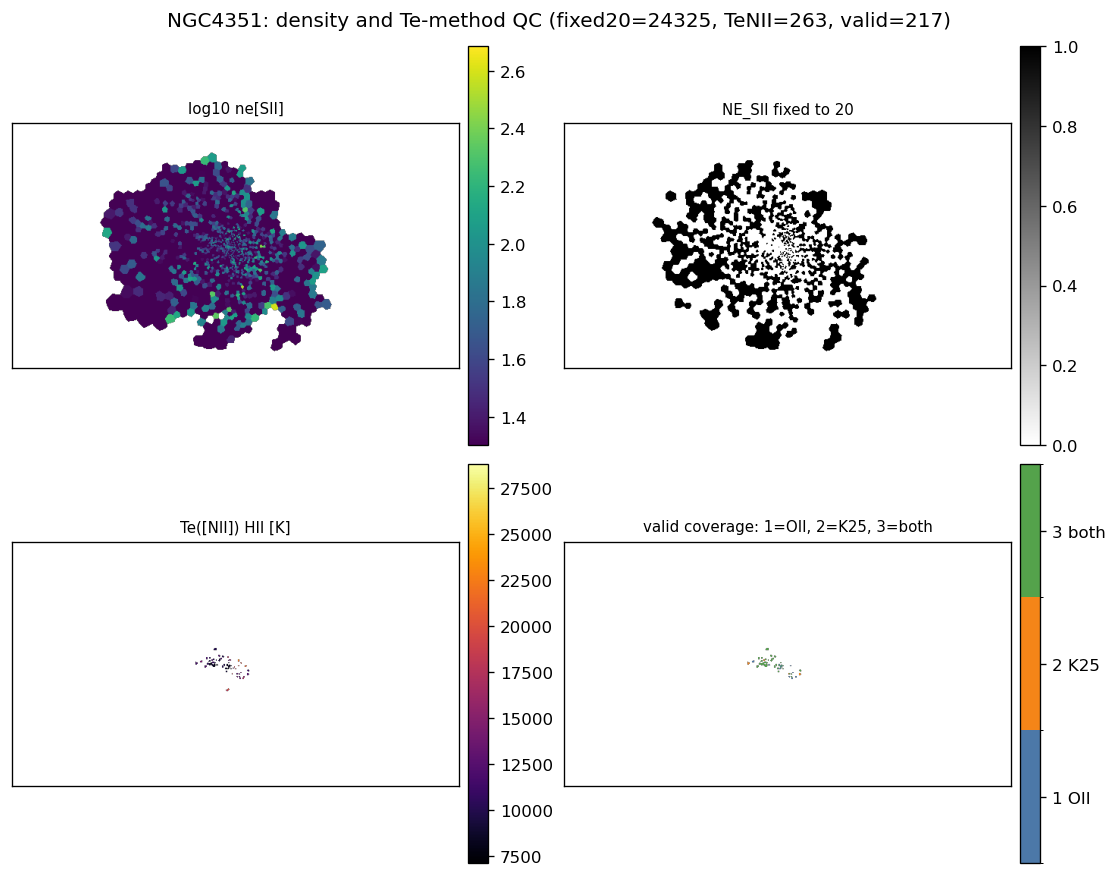

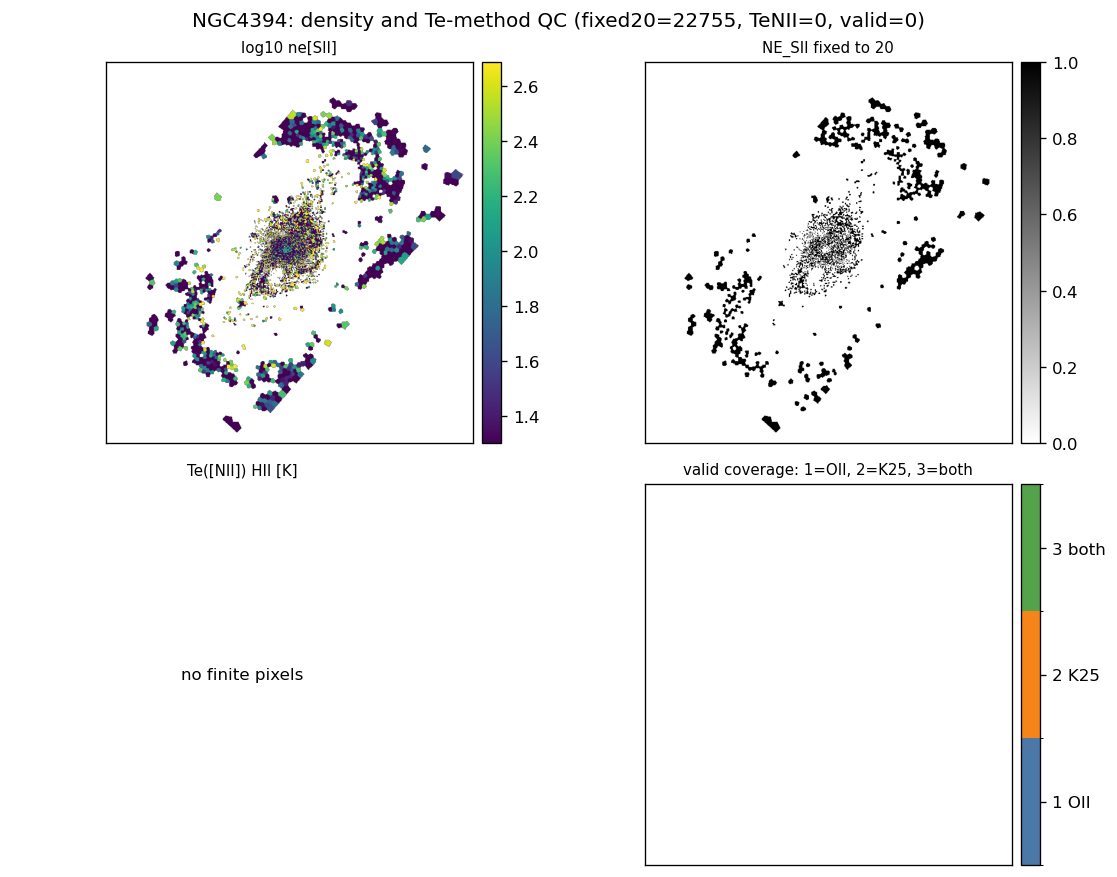

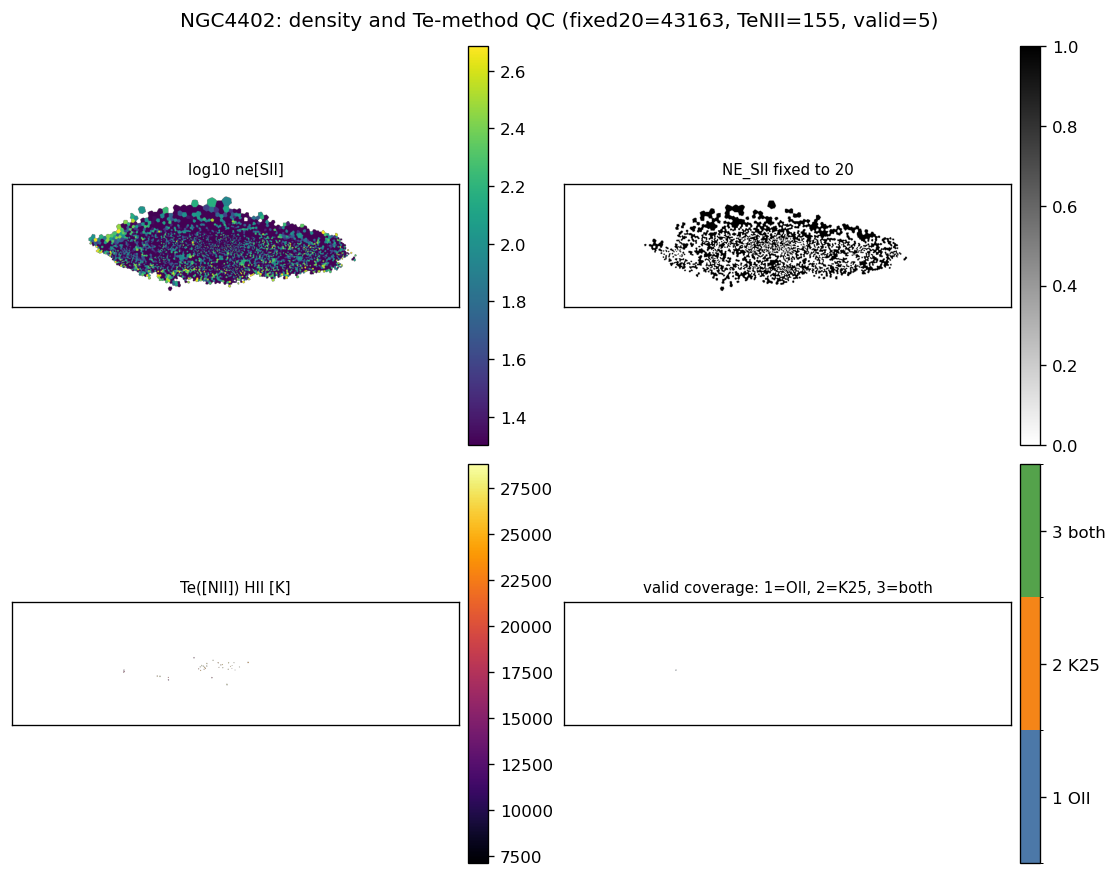

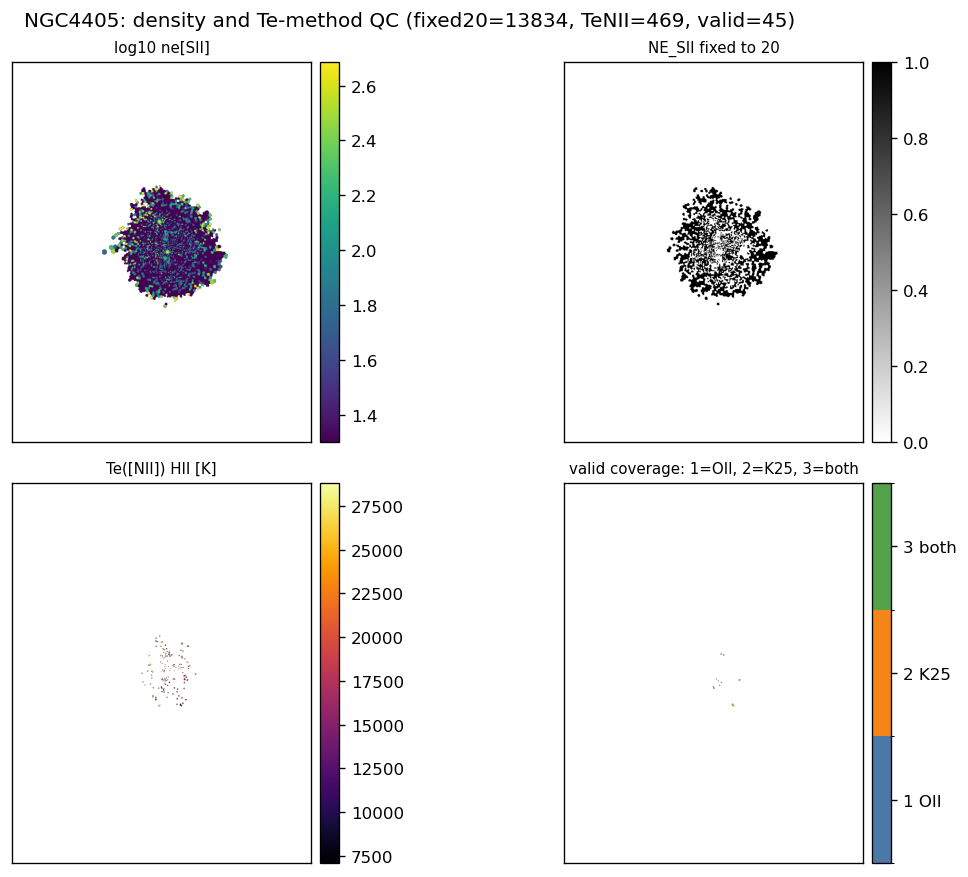

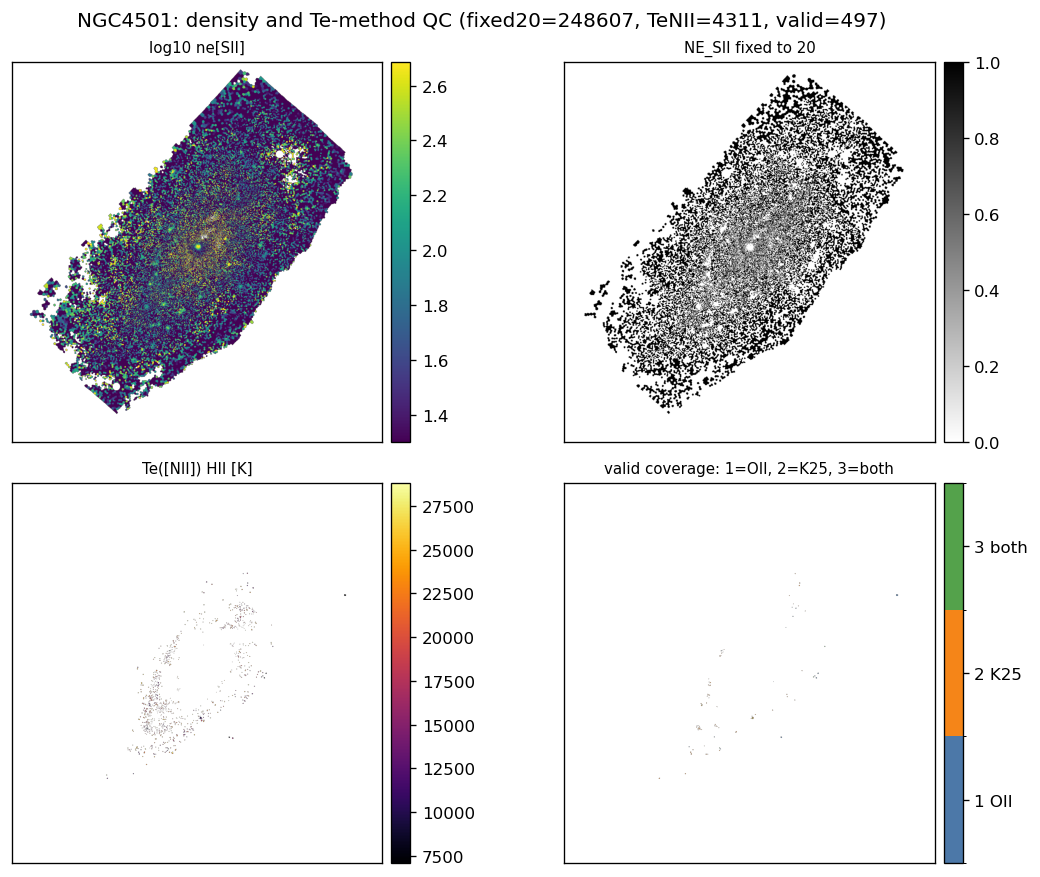

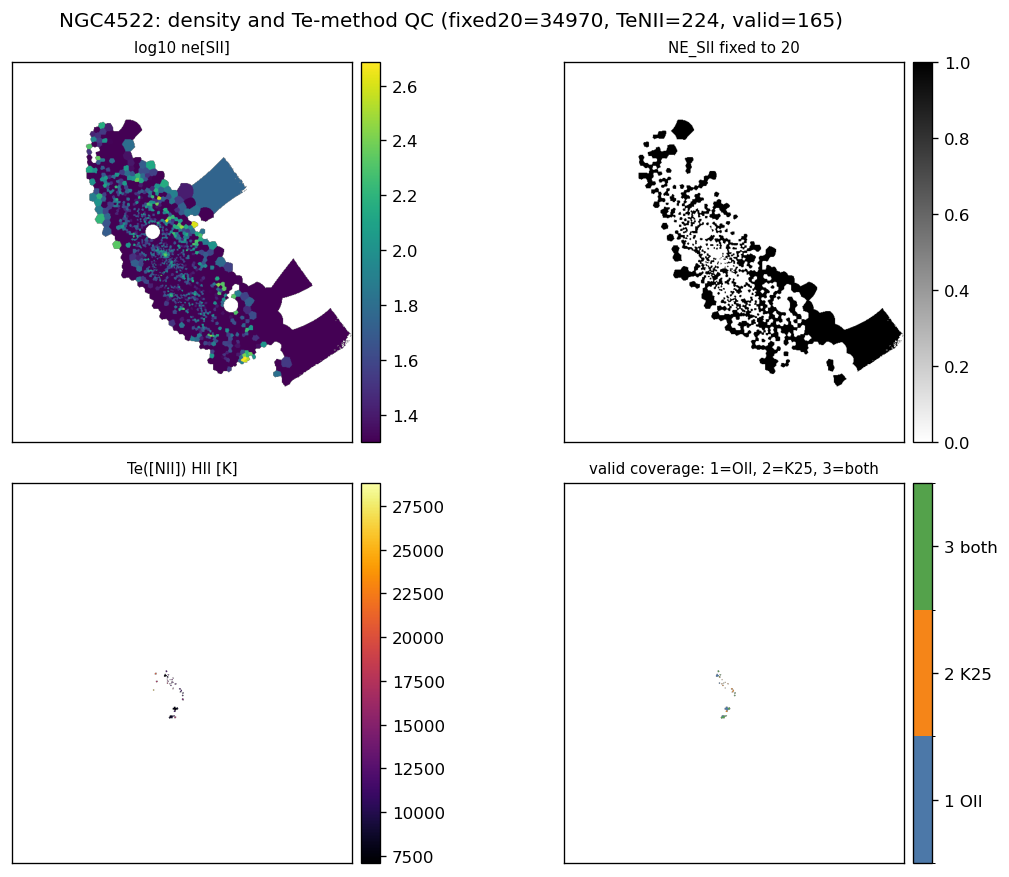

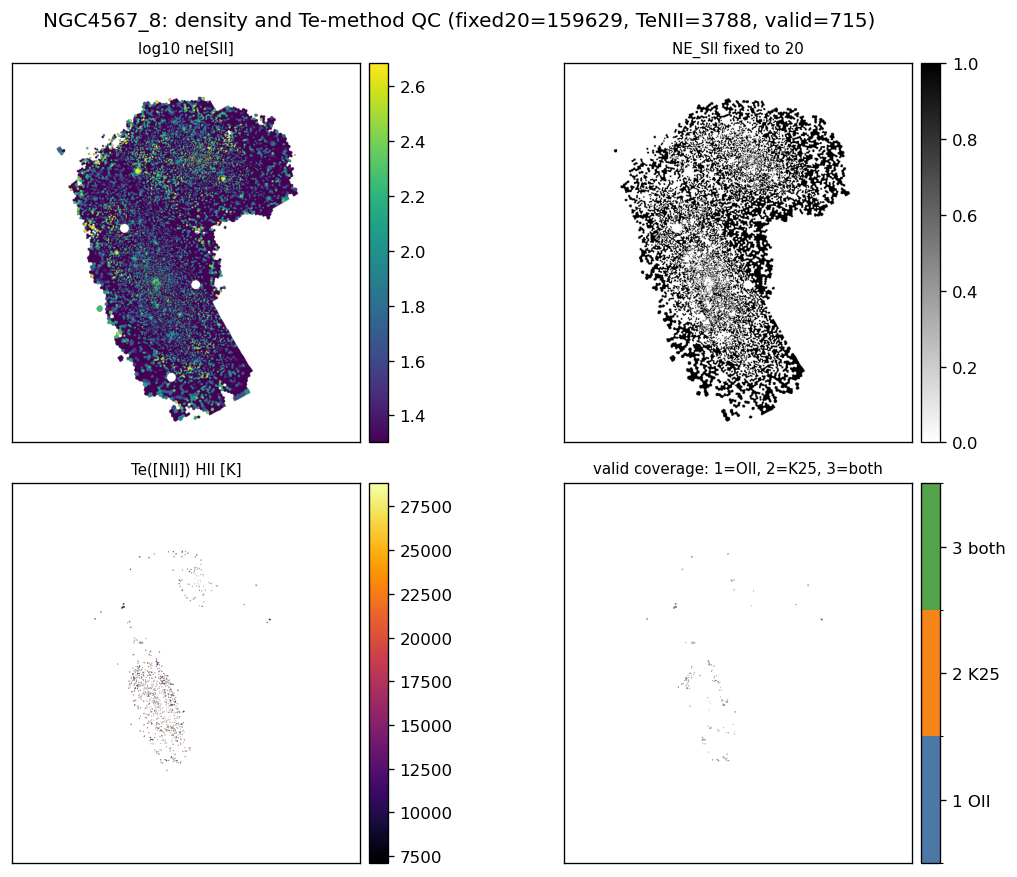

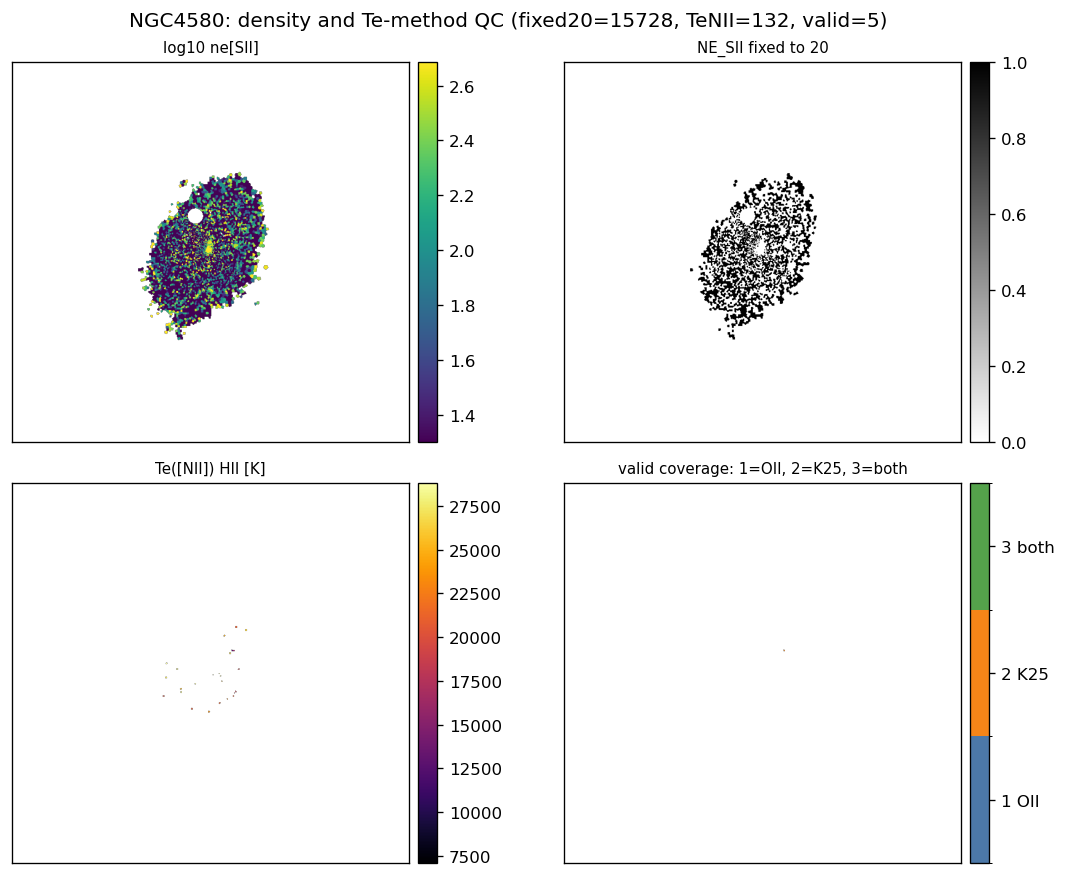

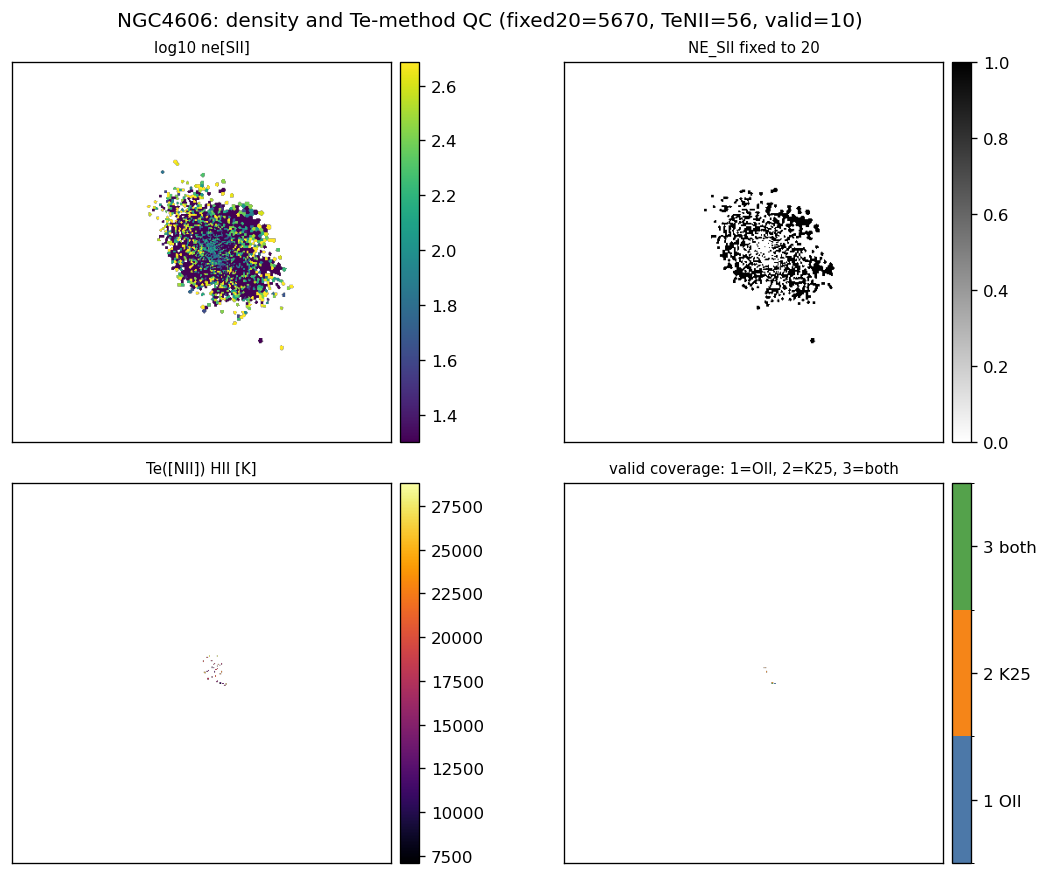

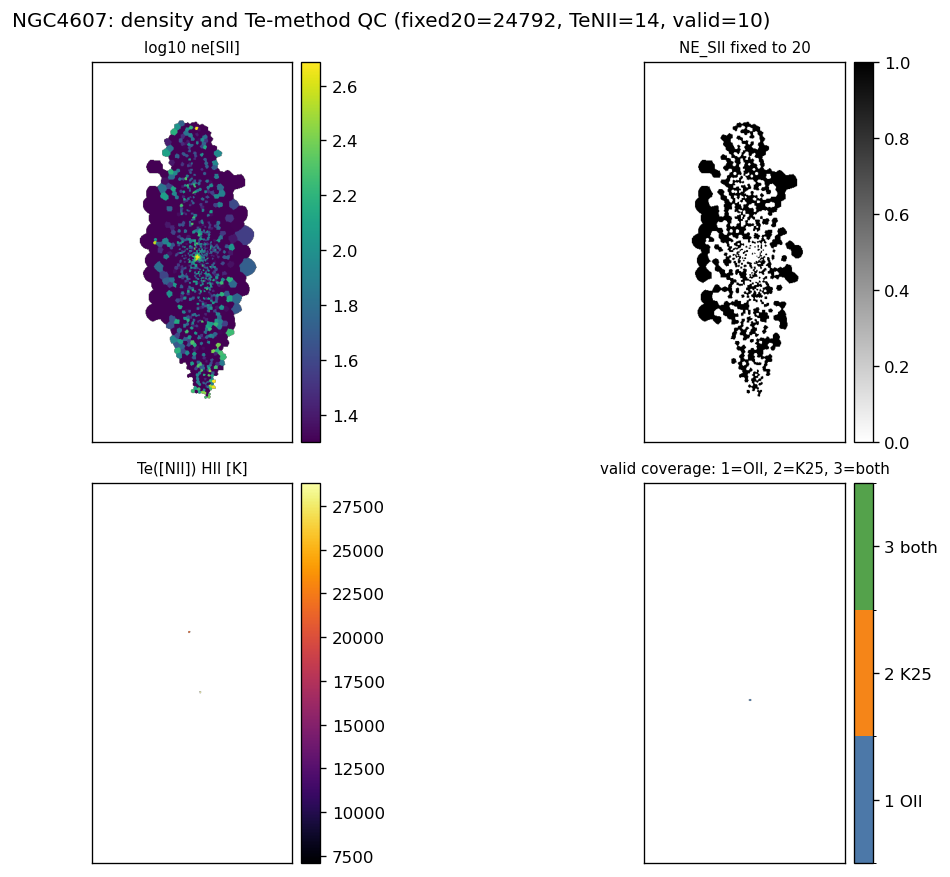

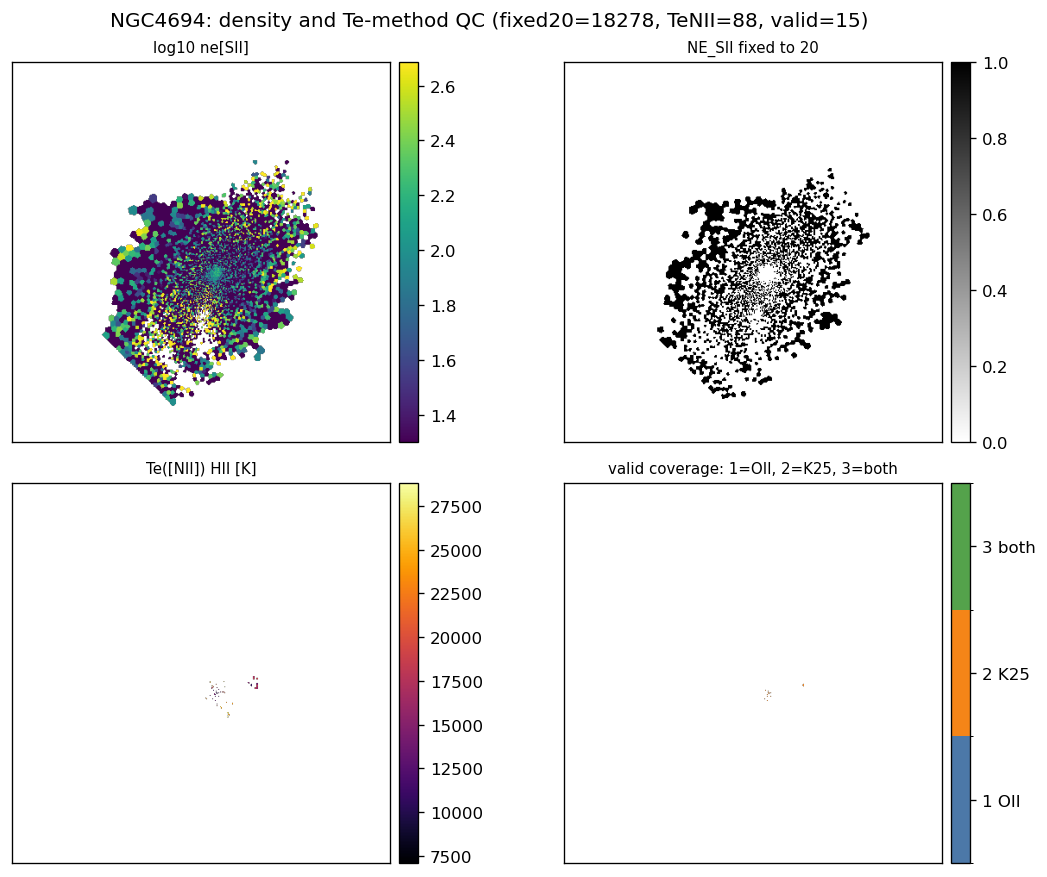

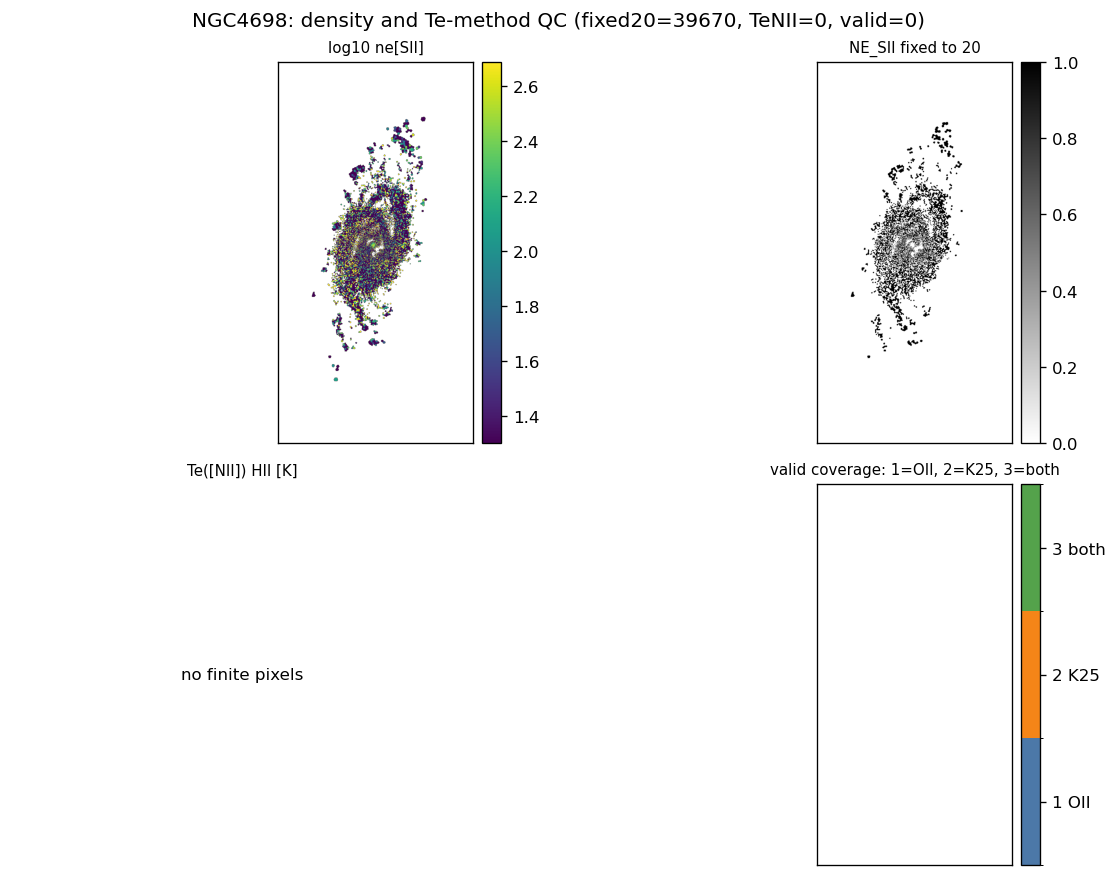

Created 18 density/Te QC 2x2 figures.


In [9]:

def build_qc_display_limits(galaxies: list[str] = AVAILABLE_GALAXIES) -> dict[str, tuple[float | None, float | None]]:
    specs = {
        "NE_SII": "log10_positive",
        "TE_NII_HII": "identity",
    }
    limits = {}
    for hdu_name, transform in specs.items():
        vals = collect_display_values(hdu_name, transform, galaxies)
        limits[hdu_name] = robust_limits_from_values(vals)
    return limits


def valid_coverage_map(gas_path: Path, target_shape: tuple[int, int]) -> np.ndarray:
    nii_oii = read_hdu(gas_path, "NII_OII7325_VALID_HII", dtype=float, required=False)
    nii_k25 = read_hdu(gas_path, "NII_K25_VALID_HII", dtype=float, required=False)
    coverage = np.zeros(target_shape, dtype=float)
    if nii_oii is not None:
        nii_oii = align_map_to_shape(nii_oii, target_shape, label="NII_OII7325_VALID_HII", fill_value=0)
        coverage += np.where(nii_oii > 0, 1, 0)
    if nii_k25 is not None:
        nii_k25 = align_map_to_shape(nii_k25, target_shape, label="NII_K25_VALID_HII", fill_value=0)
        coverage += np.where(nii_k25 > 0, 2, 0)
    return coverage


def plot_density_qc_2x2(galaxy: str, *, qc_limits: dict[str, tuple[float | None, float | None]]):
    gas_path = PRODUCTS.loc[galaxy, "gas_path"]
    ne = read_hdu(gas_path, "NE_SII", dtype=float, required=False)
    if ne is None:
        print(f"Skipping {galaxy}: missing NE_SII")
        return None
    ne_log = display_transform(ne, "log10_positive")
    fixed20 = read_hdu(gas_path, "NE_SII_FIXED20", dtype=float, required=False)
    te_nii = read_hdu(gas_path, "TE_NII_HII", dtype=float, required=False)
    fixed20 = align_map_to_shape(fixed20, ne.shape, label=f"{galaxy} NE_SII_FIXED20", fill_value=0) if fixed20 is not None else None
    te_nii = align_map_to_shape(te_nii, ne.shape, label=f"{galaxy} TE_NII_HII") if te_nii is not None else None
    coverage = valid_coverage_map(gas_path, ne.shape)

    panels = [
        ("log10 ne[SII]", ne_log, "viridis", qc_limits.get("NE_SII", (None, None))),
        ("NE_SII fixed to 20", fixed20, "gray_r", (0, 1)),
        ("Te([NII]) HII [K]", te_nii, "inferno", qc_limits.get("TE_NII_HII", (None, None))),
        ("valid coverage: 1=OII, 2=K25, 3=both", coverage, "te_valid_discrete", (0.5, 3.5)),
    ]

    valid_cmap = mpl.colors.ListedColormap(["#4C78A8", "#F58518", "#54A24B"])
    valid_norm = mpl.colors.BoundaryNorm([0.5, 1.5, 2.5, 3.5], valid_cmap.N)

    fig, axes = plt.subplots(2, 2, figsize=(9.2, 7.2), constrained_layout=True)
    for ax, (title, data, cmap, limits) in zip(axes.ravel(), panels):
        vals = finite_values(data)
        if vals.size == 0:
            ax.text(0.5, 0.5, "no finite pixels", ha="center", va="center", transform=ax.transAxes)
            ax.set_title(title, fontsize=9)
            ax.set_axis_off()
            continue
        if cmap == "te_valid_discrete":
            plot_data = np.where(data > 0, data, np.nan)
            im = ax.imshow(plot_data, origin="lower", cmap=valid_cmap, norm=valid_norm)
            cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02, ticks=[1, 2, 3])
            cb.ax.set_yticklabels(["1 OII", "2 K25", "3 both"])
        else:
            im = ax.imshow(data, origin="lower", cmap=cmap, vmin=limits[0], vmax=limits[1])
            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(title, fontsize=9)

    fixed_count = int(np.count_nonzero(fixed20 > 0)) if fixed20 is not None else 0
    te_count = int(np.count_nonzero(np.isfinite(te_nii))) if te_nii is not None else 0
    coverage_count = int(np.count_nonzero(coverage > 0))
    fig.suptitle(
        f"{galaxy}: density and Te-method QC "
        f"(fixed20={fixed_count}, TeNII={te_count}, valid={coverage_count})",
        fontsize=12,
    )
    # fig.savefig(OUTDIR / f"{galaxy}_density_te_qc_2x2.png", dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    return fig


QC_DISPLAY_LIMITS = build_qc_display_limits()
qc_rows = []
for gal in AVAILABLE_GALAXIES:
    gas_path = PRODUCTS.loc[gal, "gas_path"]
    ne = read_hdu(gas_path, "NE_SII", dtype=float, required=False)
    fixed20 = read_hdu(gas_path, "NE_SII_FIXED20", dtype=float, required=False)
    te_nii = read_hdu(gas_path, "TE_NII_HII", dtype=float, required=False)
    valid_oii = read_hdu(gas_path, "NII_OII7325_VALID_HII", dtype=float, required=False)
    valid_k25 = read_hdu(gas_path, "NII_K25_VALID_HII", dtype=float, required=False)
    ne_count = int(np.count_nonzero(np.isfinite(ne))) if ne is not None else 0
    fixed_count = int(np.count_nonzero(fixed20 > 0)) if fixed20 is not None else 0
    te_count = int(np.count_nonzero(np.isfinite(te_nii))) if te_nii is not None else 0
    oii_count = int(np.count_nonzero(valid_oii > 0)) if valid_oii is not None else 0
    k25_count = int(np.count_nonzero(valid_k25 > 0)) if valid_k25 is not None else 0
    qc_rows.append({
        "galaxy": gal,
        "ne_sii_finite": ne_count,
        "ne_sii_fixed20": fixed_count,
        "fixed20_fraction": fixed_count / ne_count if ne_count else np.nan,
        "te_nii_hii_finite": te_count,
        "nii_oii7325_valid_hii": oii_count,
        "nii_k25_valid_hii": k25_count,
    })

QC_SUMMARY = pd.DataFrame(qc_rows).set_index("galaxy")
display(QC_SUMMARY.round(4))

print(f"Making density/Te QC 2x2 figures for {len(AVAILABLE_GALAXIES)} galaxies.")
for gal in AVAILABLE_GALAXIES:
    plot_density_qc_2x2(gal, qc_limits=QC_DISPLAY_LIMITS)
print(f"Created {len(AVAILABLE_GALAXIES)} density/Te QC 2x2 figures.")


Local-context sampled points: 6,796


galaxy,IC3392,NGC4064,NGC4189,NGC4192,NGC4294,NGC4351,NGC4402,NGC4405,NGC4501,NGC4522,NGC4567_8,NGC4580,NGC4606,NGC4694
comparison_hdu,,,,,,,,,,,,,,
O_H_NII_K25_HII,0,212,56,517,1347,177,0,45,371,110,624,5,8,15
O_H_NII_OII7325_HII,11,2,279,718,1654,195,5,0,158,123,160,0,4,0


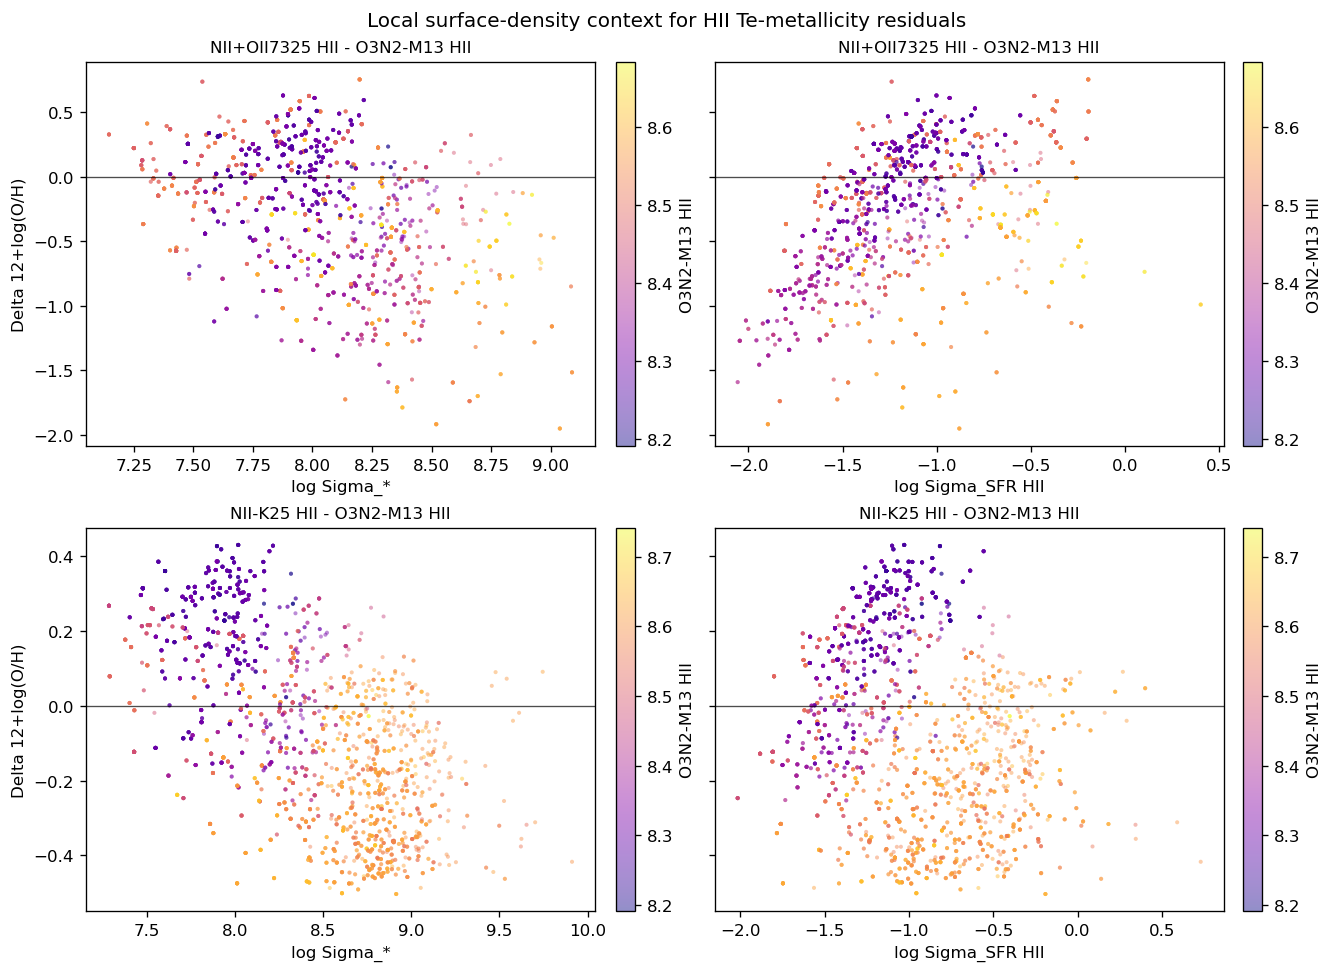

In [10]:

def sampled_local_context_points(
    galaxy: str,
    comparison_hdu: str,
    *,
    reference_hdu: str = "O_H_O3N2_M13_HII",
    max_points: int = MAX_SCATTER_POINTS_PER_GALAXY,
) -> pd.DataFrame:
    gas_path = PRODUCTS.loc[galaxy, "gas_path"]
    spatial_path = PRODUCTS.loc[galaxy, "spatial_path"]
    if spatial_path is None or not PRODUCTS.loc[galaxy, "has_spatial_mass"]:
        return pd.DataFrame()

    mass = read_hdu(spatial_path, "LOGMASS_SURFACE_DENSITY", dtype=float, required=False)
    logsfr = read_hdu(gas_path, "LOGSFR_SURFACE_DENSITY_HII", dtype=float, required=False)
    reference = read_hdu(gas_path, reference_hdu, dtype=float, required=False)
    comparison = read_hdu(gas_path, comparison_hdu, dtype=float, required=False)
    if mass is None or logsfr is None or reference is None or comparison is None:
        return pd.DataFrame()

    mass = align_map_to_shape(mass, reference.shape, label=f"{galaxy} LOGMASS_SURFACE_DENSITY")
    logsfr = align_map_to_shape(logsfr, reference.shape, label=f"{galaxy} LOGSFR_SURFACE_DENSITY_HII")
    comparison = align_map_to_shape(comparison, reference.shape, label=f"{galaxy} {comparison_hdu}")
    delta = comparison - reference
    ok = np.isfinite(mass) & np.isfinite(logsfr) & np.isfinite(reference) & np.isfinite(comparison) & np.isfinite(delta)
    flat_idx = np.flatnonzero(ok)
    if flat_idx.size == 0:
        return pd.DataFrame()
    if flat_idx.size > max_points:
        flat_idx = RNG.choice(flat_idx, size=max_points, replace=False)

    return pd.DataFrame({
        "galaxy": galaxy,
        "comparison_hdu": comparison_hdu,
        "logmass_surface_density": mass.ravel()[flat_idx],
        "logsfr_surface_density_hii": logsfr.ravel()[flat_idx],
        "o3n2_m13_hii": reference.ravel()[flat_idx],
        "comparison_oh": comparison.ravel()[flat_idx],
        "delta_vs_o3n2": delta.ravel()[flat_idx],
    })


local_frames = []
for gal in AVAILABLE_GALAXIES:
    for hdu_name in ["O_H_NII_OII7325_HII", "O_H_NII_K25_HII"]:
        frame = sampled_local_context_points(gal, hdu_name)
        if not frame.empty:
            local_frames.append(frame)

LOCAL_CONTEXT_POINTS = pd.concat(local_frames, ignore_index=True) if local_frames else pd.DataFrame()
if LOCAL_CONTEXT_POINTS.empty:
    print("No finite local-context points found. This usually means mass maps, HII SFR maps, or sparse Te metallicity maps are missing.")
else:
    print(f"Local-context sampled points: {len(LOCAL_CONTEXT_POINTS):,}")
    display(LOCAL_CONTEXT_POINTS.groupby(["comparison_hdu", "galaxy"]).size().rename("sampled_pixels").unstack(fill_value=0))

    method_labels = {
        "O_H_NII_OII7325_HII": "NII+OII7325 HII - O3N2-M13 HII",
        "O_H_NII_K25_HII": "NII-K25 HII - O3N2-M13 HII",
    }
    x_specs = [
        ("logmass_surface_density", "log Sigma_*"),
        ("logsfr_surface_density_hii", "log Sigma_SFR HII"),
    ]
    fig, axes = plt.subplots(2, 2, figsize=(11, 8), constrained_layout=True, sharey="row")
    for row, (hdu_name, method_label) in enumerate(method_labels.items()):
        sub_method = LOCAL_CONTEXT_POINTS[LOCAL_CONTEXT_POINTS["comparison_hdu"] == hdu_name]
        for col, (xcol, xlabel) in enumerate(x_specs):
            ax = axes[row, col]
            if sub_method.empty:
                ax.text(0.5, 0.5, "no finite overlap", ha="center", va="center", transform=ax.transAxes)
                ax.set_axis_off()
                continue
            sc = ax.scatter(
                sub_method[xcol],
                sub_method["delta_vs_o3n2"],
                c=sub_method["o3n2_m13_hii"],
                s=6,
                alpha=0.45,
                cmap="plasma",
                linewidths=0,
            )
            ax.axhline(0, color="black", lw=0.8, alpha=0.7)
            ax.set_xlabel(xlabel)
            ax.set_title(method_label, fontsize=10)
            cb = fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.02)
            cb.set_label("O3N2-M13 HII")
        axes[row, 0].set_ylabel("Delta 12+log(O/H)")
    fig.suptitle("Local surface-density context for HII Te-metallicity residuals", fontsize=12)
    # fig.savefig(OUTDIR / "te_metallicity_local_context_residuals.png", dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)
